In [1]:
# 필요 패키지 설치 (최초 1회 실행)
!pip install pandas matplotlib seaborn scikit-learn scipy statsmodels xgboost -q

In [2]:
# ============================================================
# 실제 데이터 로드 설정
# data/train_sample.parquet (50,000행) 사용
# ============================================================
from pathlib import Path
import pandas as pd

_nb_dir = Path().resolve()
_candidates = [
    _nb_dir / 'data' / 'train_sample.parquet',
    _nb_dir.parent / 'data' / 'train_sample.parquet',
    Path('C:/statistical_ctr_analysis/data/train_sample.parquet'),
]
PARQUET_PATH = next((p for p in _candidates if p.exists()), None)
if PARQUET_PATH is None:
    raise FileNotFoundError(
        'data/train_sample.parquet 를 찾을 수 없습니다. '
        '프로젝트 루트의 data/ 폴더에 파일이 있는지 확인하세요.'
    )
print(f'데이터 경로: {PARQUET_PATH}')


📦 테스트용 합성 데이터 생성 중 (50,000행) — 약 30초 소요...
✅ 저장 완료: train_sample_2000000.csv
   행 수: 50,000  |  CTR: 0.1525 (15.25%)
   컬럼 수: 76


In [3]:
# 한글 폰트 문제 해결을 위한 설정 코드
import matplotlib.font_manager as fm
import platform
import os

# 광고 클릭 예측 데이터 분석 - Part 1
# 타겟 분석 + 시간 패턴 + 사용자 세그먼트 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# # 한글 폰트 설정 (선택사항)
# plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']
# plt.rcParams['axes.unicode_minus'] = False

# 기본 스타일 설정
plt.style.use('default')
sns.set_palette("husl")

def setup_korean_font():
    """운영체제별 한글 폰트 설정"""
    
    print("🔍 현재 시스템:", platform.system())
    print("🔍 사용 가능한 폰트 확인 중...")
    
    # 운영체제별 한글 폰트 리스트
    korean_fonts = {
        'Windows': [
            'Malgun Gothic',
            'Microsoft YaHei', 
            'SimHei',
            'NanumGothic',
            'NanumBarunGothic'
        ],
        'Darwin': [  # macOS
            'AppleGothic',
            'Apple SD Gothic Neo',
            'NanumGothic',
            'NanumBarunGothic'
        ],
        'Linux': [
            'DejaVu Sans',
            'NanumGothic',
            'NanumBarunGothic',
            'UnDotum'
        ]
    }
    
    # 시스템에 설치된 폰트 목록
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # 운영체제에 맞는 한글 폰트 찾기
    system = platform.system()
    fonts_to_try = korean_fonts.get(system, korean_fonts['Linux'])
    
    found_font = None
    for font in fonts_to_try:
        if font in available_fonts:
            found_font = font
            break
    
    if found_font:
        plt.rcParams['font.family'] = found_font
        plt.rcParams['axes.unicode_minus'] = False
        print(f"✅ 한글 폰트 설정 완료: {found_font}")
        return True
    else:
        print("❌ 적절한 한글 폰트를 찾을 수 없습니다.")
        print("📋 설치된 폰트 중 일부:")
        print([f for f in available_fonts if any(keyword in f.lower() for keyword in ['gothic', 'nanum', 'malgun'])][:10])
        return False

def test_korean_display():
    """한글 출력 테스트"""
    import matplotlib.pyplot as plt
    import numpy as np
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 테스트 데이터
    x = ['월', '화', '수', '목', '금', '토', '일']
    y = np.random.rand(7)
    
    ax.bar(x, y)
    ax.set_title('한글 폰트 테스트')
    ax.set_xlabel('요일')
    ax.set_ylabel('값')
    
    plt.tight_layout()
    plt.show()
    
    print("위 차트에서 한글이 정상적으로 보이나요?")

setup_korean_font()
# # 폰트 설정 실행
# if setup_korean_font():
#     test_korean_display()
# else:
#     print("\n💡 해결 방법:")
#     print("1. 나눔고딕 폰트 설치: https://hangeul.naver.com/2017/nanum")
#     print("2. 영어 버전 코드 사용")
#     print("3. 폰트 캐시 초기화: matplotlib 폰트 캐시 삭제")

# # 폰트 캐시 초기화 함수 (필요시 사용)
# def clear_matplotlib_cache():
#     """matplotlib 폰트 캐시 초기화"""
#     try:
#         import matplotlib
#         cache_dir = matplotlib.get_cachedir()
#         print(f"캐시 디렉토리: {cache_dir}")
        
#         # 캐시 파일들 삭제
#         for file in os.listdir(cache_dir):
#             if file.endswith('.cache'):
#                 os.remove(os.path.join(cache_dir, file))
#                 print(f"삭제됨: {file}")
        
#         print("✅ 폰트 캐시 초기화 완료")
#         print("🔄 Python 재시작 후 다시 시도해주세요")
        
#     except Exception as e:
#         print(f"❌ 캐시 초기화 실패: {e}")

# # 필요시 캐시 초기화 실행
# # clear_matplotlib_cache()

🔍 현재 시스템: Windows
🔍 사용 가능한 폰트 확인 중...
✅ 한글 폰트 설정 완료: Malgun Gothic


True

In [4]:
print("🎯 광고 클릭 예측 데이터 분석 시작!")
print("=" * 60)

# ========================================
# 📊 1. 데이터 로드 및 기본 정보
# ========================================

# 데이터 로드
import os

csv_path = 'train_sample_2000000.csv'

# 파일이 없을 경우 경로 탐색
if not os.path.exists(csv_path):
    search_dirs = ['.', '..', '../data', '../../data', os.path.expanduser('~')]
    for d in search_dirs:
        candidate = os.path.join(d, csv_path)
        if os.path.exists(candidate):
            csv_path = candidate
            print(f"✅ 파일 발견: {os.path.abspath(csv_path)}")
            break
    else:
        raise FileNotFoundError(
            f"'{csv_path}' 파일을 찾을 수 없습니다.\n"
            f"현재 작업 디렉토리: {os.getcwd()}\n"
            f"파일을 올바른 경로에 배치하거나 csv_path 변수를 수정해주세요."
        )

df = pd.read_csv(csv_path)

print("📋 데이터 기본 정보:")
print(f"   총 샘플 수: {len(df):,}")
print(f"   총 컬럼 수: {len(df.columns)}")
print(f"   메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 결측값 확인
missing_info = df.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)
if len(missing_info) > 0:
    print(f"\n⚠️  결측값이 있는 컬럼: {len(missing_info)}개")
    print(missing_info.head(10))
else:
    print("\n✅ 결측값 없음")

print(f"\n📊 데이터 타입 분포:")
print(df.dtypes.value_counts())
print(df.info())
display(df.describe())

🎯 광고 클릭 예측 데이터 분석 시작!
📋 데이터 기본 정보:
   총 샘플 수: 50,000
   총 컬럼 수: 76
   메모리 사용량: 128.41 MB

⚠️  결측값이 있는 컬럼: 5개
feat_b_4    7540
feat_b_1    7490
feat_b_5    7458
feat_b_2    7445
feat_b_3    7402
dtype: int64

📊 데이터 타입 분포:
float64    69
int64       6
object      1
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 76 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hour          50000 non-null  int64  
 1   day_of_week   50000 non-null  int64  
 2   gender        50000 non-null  int64  
 3   age_group     50000 non-null  int64  
 4   inventory_id  50000 non-null  int64  
 5   seq           50000 non-null  object 
 6   l_feat_1      50000 non-null  float64
 7   l_feat_2      50000 non-null  float64
 8   l_feat_3      50000 non-null  float64
 9   l_feat_4      50000 non-null  float64
 10  l_feat_5      50000 non-null  float64
 11  l_feat_6      50000 non-null  float64


,hour,day_of_week,gender,age_group,inventory_id,l_feat_1,l_feat_2,l_feat_3,l_feat_4,l_feat_5,...,history_b_22,history_b_23,history_b_24,history_b_25,history_b_26,history_b_27,history_b_28,history_b_29,history_b_30,clicked
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,11.577400,2.996700,1.429320,2.493740,12.248820,-0.001840,0.001737,-0.006977,-0.018323,-0.005332,...,3.004402,3.005945,2.990546,3.004097,3.017198,2.996103,3.017297,2.988118,2.985808,0.152480
std,6.909099,1.998151,0.586149,1.706534,10.116804,1.001965,1.001969,0.998437,0.995249,1.005070,...,3.001356,2.988039,2.973553,2.979869,3.033611,3.006379,3.042967,2.985052,2.970476,0.359489
min,0.000000,0.000000,0.000000,0.000000,0.000000,-4.877960,-4.546497,-4.301849,-3.879777,-4.646981,...,0.000210,0.000150,0.000039,0.000116,0.000045,0.000086,0.000102,0.000021,0.000034,0.000000
25%,6.000000,1.000000,1.000000,1.000000,4.000000,-0.678780,-0.674529,-0.671469,-0.685885,-0.690100,...,0.863489,0.864700,0.864486,0.863907,0.864974,0.866053,0.862699,0.858016,0.856697,0.000000
50%,12.000000,3.000000,1.000000,2.000000,10.000000,0.004508,0.002396,-0.010704,-0.017362,0.000282,...,2.082067,2.086725,2.083967,2.091607,2.083046,2.077025,2.085982,2.067883,2.059207,0.000000
75%,18.000000,5.000000,2.000000,4.000000,18.000000,0.670650,0.674675,0.663551,0.651307,0.668884,...,4.173725,4.195009,4.155284,4.161658,4.183019,4.141054,4.179808,4.146873,4.149470,0.000000
max,23.000000,6.000000,2.000000,5.000000,49.000000,4.300515,4.212574,4.451923,4.077125,4.427428,...,33.756131,30.234779,29.519545,31.505067,34.493728,35.060188,33.064862,35.625766,37.427629,1.000000



🎯 타겟 변수 (clicked) 분석
📈 전체 클릭률: 0.1525 (15.25%)
🔢 총 클릭 수: 7,624 / 50,000
⚖️  클래스 불균형 비율: 5.6:1 (Non-click:Click)


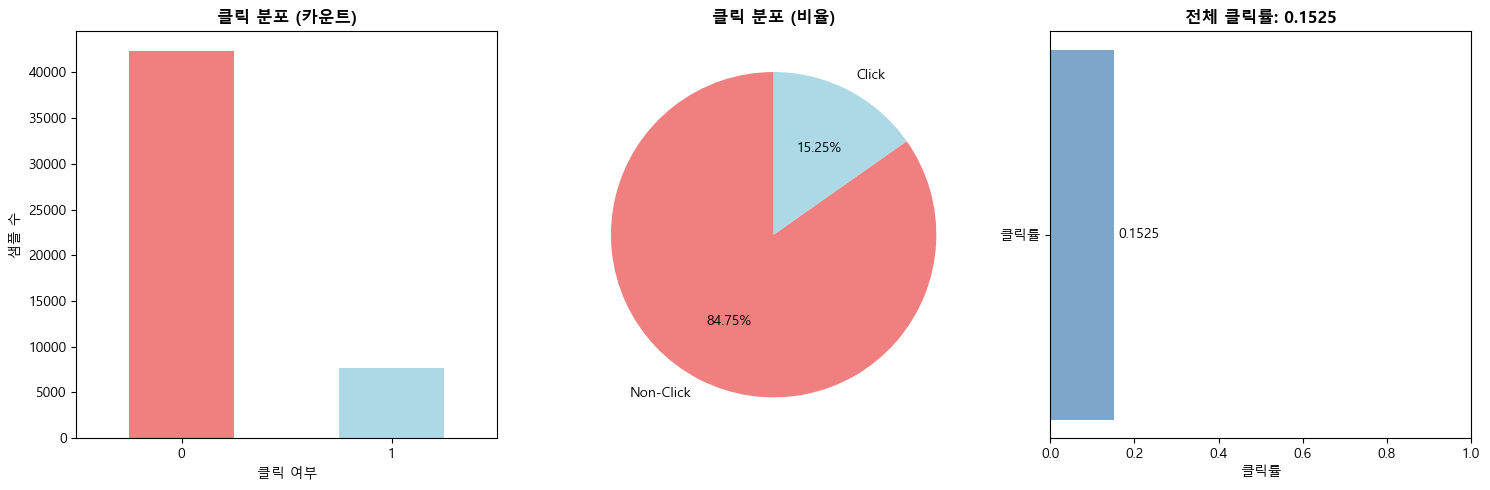

In [5]:

# ========================================
# 🎯 2. 타겟 변수 (clicked) 분석
# ========================================

print("\n" + "="*60)
print("🎯 타겟 변수 (clicked) 분석")
print("="*60)

# 클릭률 계산
click_rate = df['clicked'].mean()
total_clicks = df['clicked'].sum()
total_samples = len(df)

print(f"📈 전체 클릭률: {click_rate:.4f} ({click_rate*100:.2f}%)")
print(f"🔢 총 클릭 수: {total_clicks:,} / {total_samples:,}")
print(f"⚖️  클래스 불균형 비율: {(1-click_rate)/click_rate:.1f}:1 (Non-click:Click)")

# 타겟 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 클릭 분포 (카운트)
df['clicked'].value_counts().plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightblue'])
axes[0].set_title('클릭 분포 (카운트)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('클릭 여부')
axes[0].set_ylabel('샘플 수')
axes[0].tick_params(axis='x', rotation=0)

# 클릭 분포 (비율) - 파이차트
sizes = df['clicked'].value_counts()
labels = ['Non-Click', 'Click']
colors = ['lightcoral', 'lightblue']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.2f%%', startangle=90)
axes[1].set_title('클릭 분포 (비율)', fontsize=12, fontweight='bold')

# 클릭률 시각화 (게이지 형태)
axes[2].barh(['클릭률'], [click_rate], color='steelblue', alpha=0.7)
axes[2].set_xlim(0, 1)
axes[2].set_title(f'전체 클릭률: {click_rate:.4f}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('클릭률')
for i, v in enumerate([click_rate]):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()


⏰ 시간 패턴 분석
📊 시간대별 통계 (상위 5개):
      총_샘플수  클릭수     클릭률
hour                    
18     2070  426  0.2058
15     2169  446  0.2056
14     2179  436  0.2001
17     2068  413  0.1997
12     2161  431  0.1994

📊 요일별 통계:
   총_샘플수   클릭수     클릭률
월   7143  1061  0.1485
화   7201  1071  0.1487
수   7063  1090  0.1543
목   7180  1066  0.1485
금   7153  1145  0.1601
토   7204  1084  0.1505
일   7056  1107  0.1569


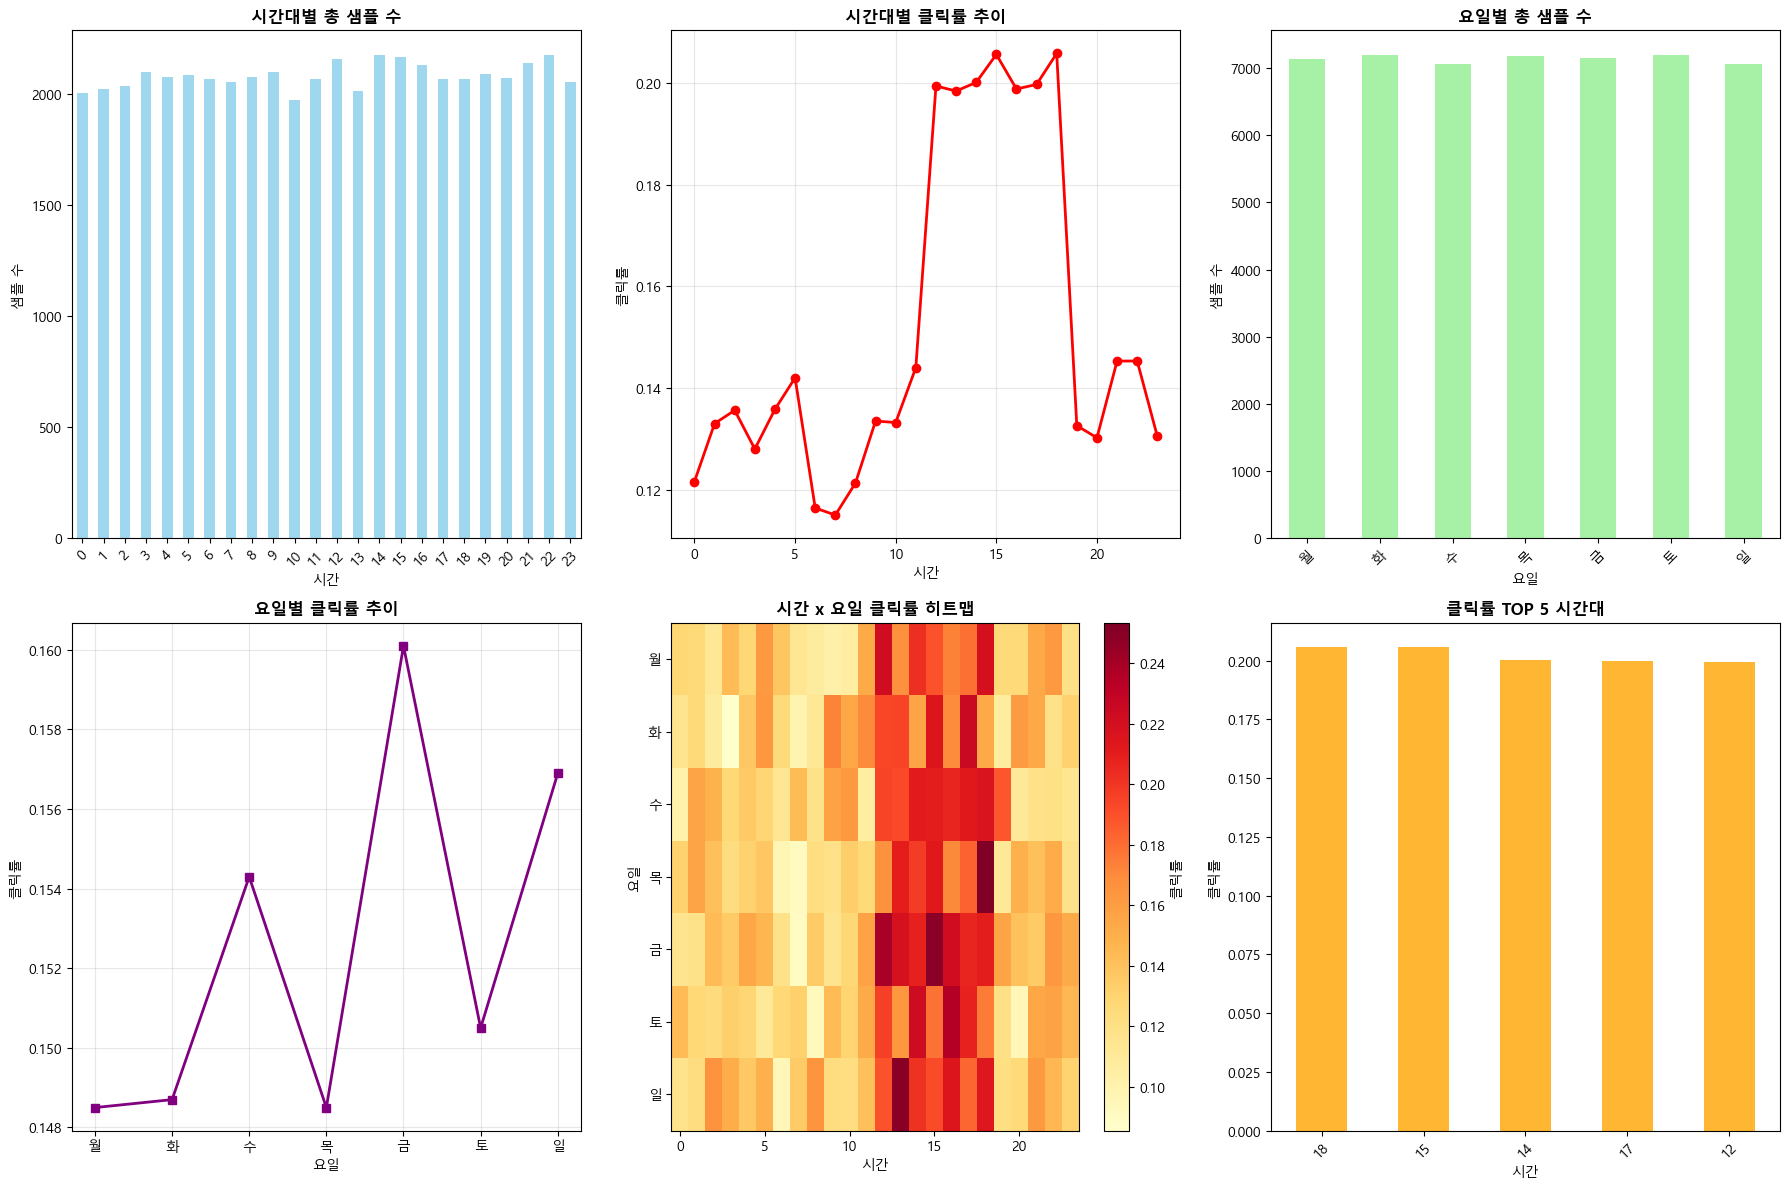


🕐 시간 패턴 인사이트:
   최고 클릭률 시간: 18시 (0.2058)
   최저 클릭률 시간: 7시 (0.1150)
   최고 클릭률 요일: 금 (0.1601)
   최저 클릭률 요일: 월 (0.1485)


In [6]:

# ========================================
# ⏰ 3. 시간 패턴 분석
# ========================================

print("\n" + "="*60)
print("⏰ 시간 패턴 분석")
print("="*60)

# 시간대별 활동 패턴
hourly_stats = df.groupby('hour').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
hourly_stats.columns = ['총_샘플수', '클릭수', '클릭률']

print("📊 시간대별 통계 (상위 5개):")
print(hourly_stats.sort_values('클릭률', ascending=False).head())

# 요일별 활동 패턴 (day_of_week: 0=월 ~ 6=일)
daily_stats = df.groupby('day_of_week').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
daily_stats.columns = ['총_샘플수', '클릭수', '클릭률']

print(f"\n📊 요일별 통계:")
day_names = ['월', '화', '수', '목', '금', '토', '일']
daily_stats.index = [day_names[i] if i < len(day_names) else f'Day_{i}' for i in daily_stats.index]
print(daily_stats)

# 시간 패턴 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 시간대별 샘플 수
hourly_stats['총_샘플수'].plot(kind='bar', ax=axes[0,0], color='skyblue', alpha=0.8)
axes[0,0].set_title('시간대별 총 샘플 수', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('시간')
axes[0,0].set_ylabel('샘플 수')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. 시간대별 클릭률
hourly_stats['클릭률'].plot(kind='line', ax=axes[0,1], color='red', marker='o', linewidth=2)
axes[0,1].set_title('시간대별 클릭률 추이', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('시간')
axes[0,1].set_ylabel('클릭률')
axes[0,1].grid(True, alpha=0.3)

# 3. 요일별 샘플 수
daily_stats['총_샘플수'].plot(kind='bar', ax=axes[0,2], color='lightgreen', alpha=0.8)
axes[0,2].set_title('요일별 총 샘플 수', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('요일')
axes[0,2].set_ylabel('샘플 수')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. 요일별 클릭률
daily_stats['클릭률'].plot(kind='line', ax=axes[1,0], color='purple', marker='s', linewidth=2)
axes[1,0].set_title('요일별 클릭률 추이', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('요일')
axes[1,0].set_ylabel('클릭률')
axes[1,0].grid(True, alpha=0.3)

# 5. 시간 x 요일 히트맵 (클릭률)
pivot_table = df.groupby(['day_of_week', 'hour'])['clicked'].mean().unstack()
im = axes[1,1].imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
axes[1,1].set_title('시간 x 요일 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('시간')
axes[1,1].set_ylabel('요일')
axes[1,1].set_yticks(range(len(pivot_table.index)))
axes[1,1].set_yticklabels([day_names[i] if i < len(day_names) else f'Day_{i}' for i in pivot_table.index])
plt.colorbar(im, ax=axes[1,1], label='클릭률')

# 6. 피크 시간대 분석
peak_hours = hourly_stats.nlargest(5, '클릭률')
peak_hours.index.name = '시간'
peak_hours['클릭률'].plot(kind='bar', ax=axes[1,2], color='orange', alpha=0.8)
axes[1,2].set_title('클릭률 TOP 5 시간대', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('시간')
axes[1,2].set_ylabel('클릭률')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 시간 인사이트 출력
print(f"\n🕐 시간 패턴 인사이트:")
peak_hour = hourly_stats['클릭률'].idxmax()
low_hour = hourly_stats['클릭률'].idxmin()
print(f"   최고 클릭률 시간: {peak_hour}시 ({hourly_stats.loc[peak_hour, '클릭률']:.4f})")
print(f"   최저 클릭률 시간: {low_hour}시 ({hourly_stats.loc[low_hour, '클릭률']:.4f})")

peak_day = daily_stats['클릭률'].idxmax()
low_day = daily_stats['클릭률'].idxmin()
print(f"   최고 클릭률 요일: {peak_day} ({daily_stats.loc[peak_day, '클릭률']:.4f})")
print(f"   최저 클릭률 요일: {low_day} ({daily_stats.loc[low_day, '클릭률']:.4f})")



👥 사용자 세그먼트 분석
📊 성별 통계:
        총_샘플수   클릭수     클릭률
gender                     
0        2464   379  0.1538
1       23606  3643  0.1543
2       23930  3602  0.1505

📊 연령그룹 통계:
           총_샘플수   클릭수     클릭률
age_group                     
1           8352  1508  0.1806
0           8356  1415  0.1693
2           8392  1403  0.1672
3           8334  1221  0.1465
4           8281  1079  0.1303
5           8285   998  0.1205

📊 성별 x 연령그룹 교차 분석 (클릭률 상위 10개):
                  총_샘플수  클릭수     클릭률
gender age_group                    
0      1            407   81  0.1990
2      1           3970  725  0.1826
1      2           3971  709  0.1785
       1           3975  702  0.1766
       0           3922  683  0.1741
0      0            408   70  0.1716
2      0           4026  662  0.1644
       2           3983  626  0.1572
0      2            438   68  0.1553
2      3           3984  595  0.1493


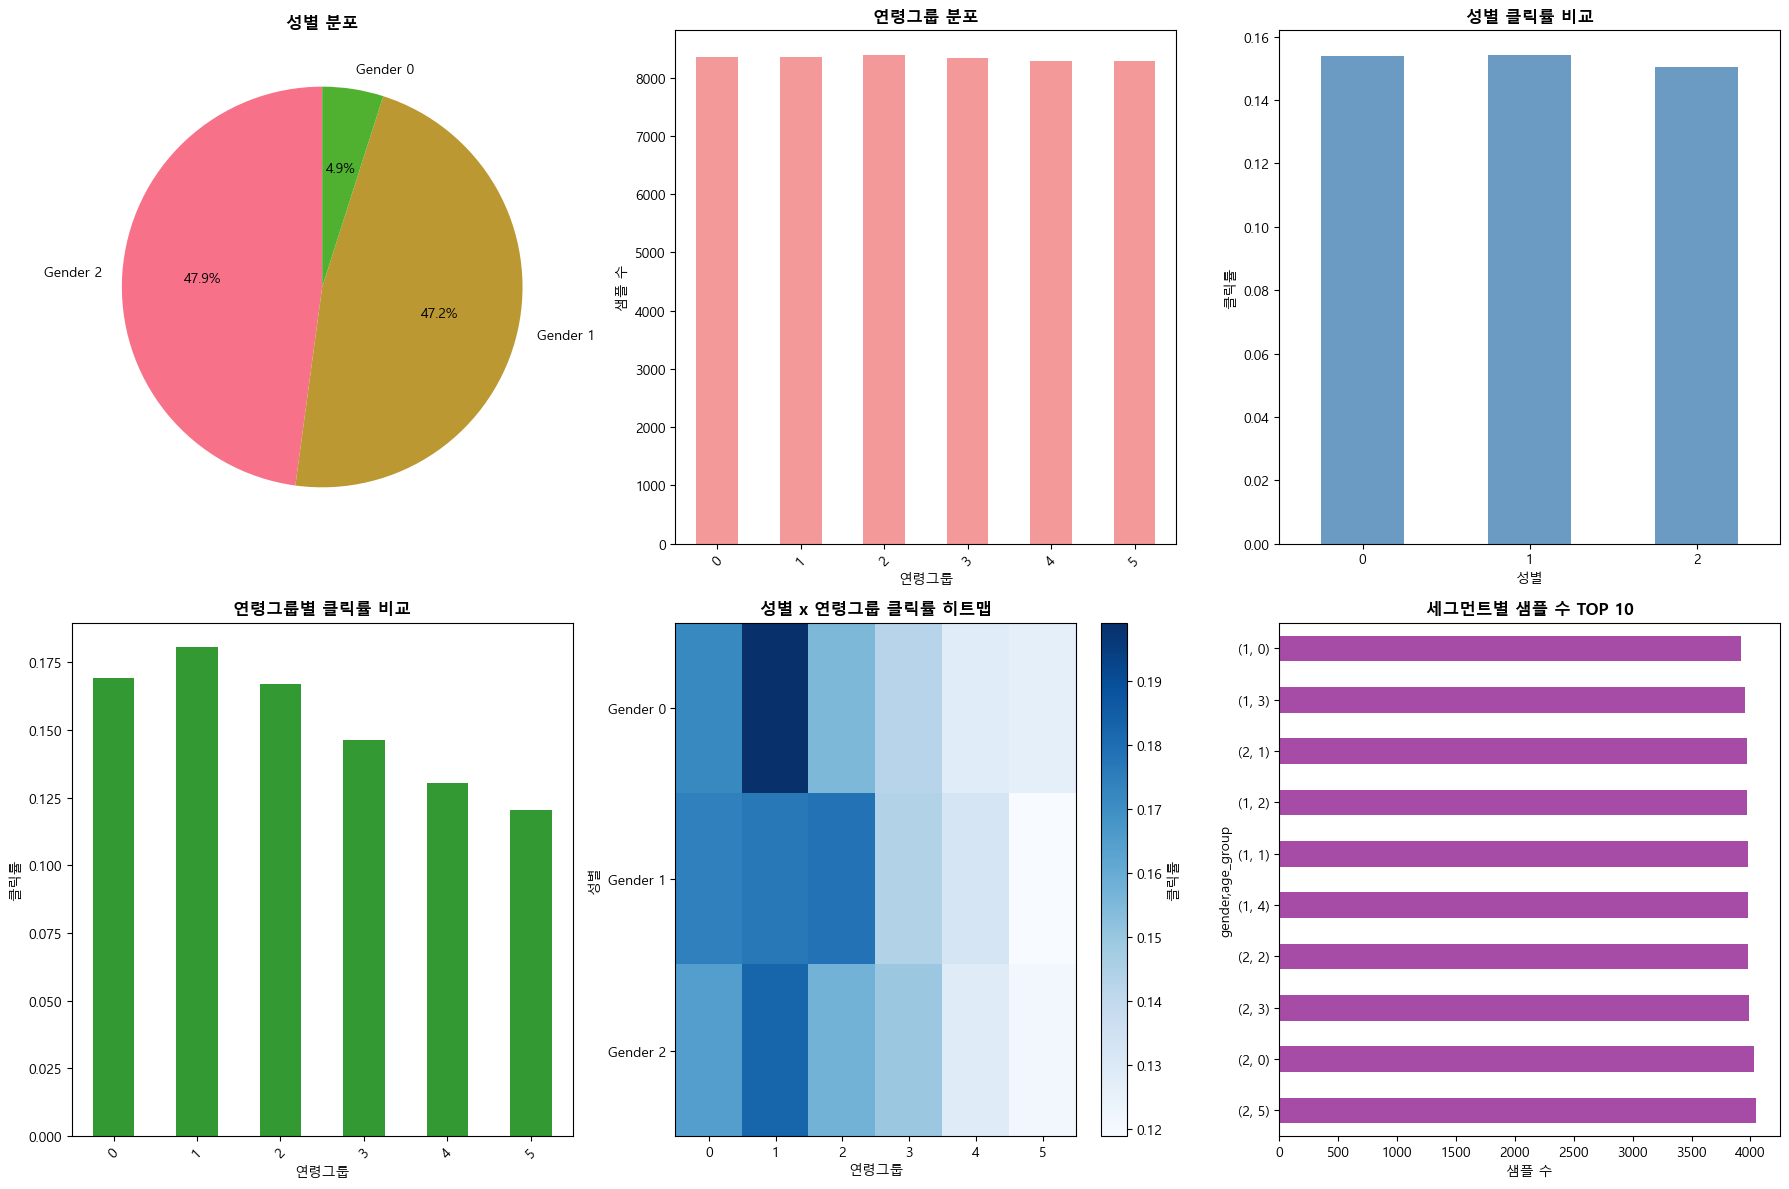


👥 세그먼트 인사이트:
   최고 클릭률 성별: Gender 1 (0.1543)
   최고 클릭률 연령: Age 1 (0.1806)
   최고 클릭률 세그먼트: Gender 0, Age 1 (0.1990)


In [7]:

# ========================================
# 👥 4. 사용자 세그먼트 분석
# ========================================

print("\n" + "="*60)
print("👥 사용자 세그먼트 분석")
print("="*60)

# 성별 분석
gender_stats = df.groupby('gender').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
gender_stats.columns = ['총_샘플수', '클릭수', '클릭률']

print("📊 성별 통계:")
print(gender_stats)

# 연령그룹 분석
age_stats = df.groupby('age_group').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
age_stats.columns = ['총_샘플수', '클릭수', '클릭률']

print(f"\n📊 연령그룹 통계:")
print(age_stats.sort_values('클릭률', ascending=False))

# 성별 x 연령그룹 교차 분석
cross_analysis = df.groupby(['gender', 'age_group']).agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
cross_analysis.columns = ['총_샘플수', '클릭수', '클릭률']

print(f"\n📊 성별 x 연령그룹 교차 분석 (클릭률 상위 10개):")
print(cross_analysis.sort_values('클릭률', ascending=False).head(10))

# 사용자 세그먼트 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 성별 분포
gender_counts = df['gender'].value_counts()
axes[0,0].pie(gender_counts.values, labels=[f'Gender {i}' for i in gender_counts.index], 
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('성별 분포', fontsize=12, fontweight='bold')

# 2. 연령그룹 분포
age_counts = df['age_group'].value_counts().sort_index()
age_counts.plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
axes[0,1].set_title('연령그룹 분포', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('연령그룹')
axes[0,1].set_ylabel('샘플 수')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. 성별 클릭률 비교
gender_stats['클릭률'].plot(kind='bar', ax=axes[0,2], color='steelblue', alpha=0.8)
axes[0,2].set_title('성별 클릭률 비교', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('성별')
axes[0,2].set_ylabel('클릭률')
axes[0,2].tick_params(axis='x', rotation=0)

# 4. 연령그룹 클릭률 비교
age_stats['클릭률'].plot(kind='bar', ax=axes[1,0], color='green', alpha=0.8)
axes[1,0].set_title('연령그룹별 클릭률 비교', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('연령그룹')
axes[1,0].set_ylabel('클릭률')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. 성별 x 연령그룹 히트맵 (클릭률)
pivot_cross = df.groupby(['gender', 'age_group'])['clicked'].mean().unstack(fill_value=0)
im2 = axes[1,1].imshow(pivot_cross.values, cmap='Blues', aspect='auto')
axes[1,1].set_title('성별 x 연령그룹 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('연령그룹')
axes[1,1].set_ylabel('성별')
axes[1,1].set_yticks(range(len(pivot_cross.index)))
axes[1,1].set_yticklabels([f'Gender {i}' for i in pivot_cross.index])
axes[1,1].set_xticks(range(len(pivot_cross.columns)))
axes[1,1].set_xticklabels(pivot_cross.columns)
plt.colorbar(im2, ax=axes[1,1], label='클릭률')

# 6. 세그먼트별 샘플 수 비교
cross_samples = df.groupby(['gender', 'age_group']).size().sort_values(ascending=False).head(10)
cross_samples.plot(kind='barh', ax=axes[1,2], color='purple', alpha=0.7)
axes[1,2].set_title('세그먼트별 샘플 수 TOP 10', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('샘플 수')

plt.tight_layout()
plt.show()

# 세그먼트 인사이트 출력
print(f"\n👥 세그먼트 인사이트:")
best_gender = gender_stats['클릭률'].idxmax()
best_age = age_stats['클릭률'].idxmax()
best_segment = cross_analysis['클릭률'].idxmax()

print(f"   최고 클릭률 성별: Gender {best_gender} ({gender_stats.loc[best_gender, '클릭률']:.4f})")
print(f"   최고 클릭률 연령: Age {best_age} ({age_stats.loc[best_age, '클릭률']:.4f})")
print(f"   최고 클릭률 세그먼트: Gender {best_segment[0]}, Age {best_segment[1]} ({cross_analysis.loc[best_segment, '클릭률']:.4f})")


🔍 Part 2: 시퀀스 분석 + 피처 상관관계 분석
📊 로드된 데이터: 50,000 샘플

🔗 시퀀스 데이터 (seq) 분석
📏 시퀀스 길이 통계:
count    50000.000000
mean       427.933560
std        216.496585
min         50.000000
25%        241.000000
50%        429.000000
75%        615.000000
max        799.000000
Name: seq_length, dtype: float64

📊 시퀀스 길이별 클릭률 (상위 10개):
            샘플수  클릭수     클릭률
seq_length                  
363          52   17  0.3269
355          57   18  0.3158
595          59   18  0.3051
799          72   21  0.2917
117          57   16  0.2807
265          68   19  0.2794
455          66   18  0.2727
573          70   19  0.2714
353          64   17  0.2656
276          53   14  0.2642

📊 시퀀스 길이 구간별 분석:
                  샘플수   클릭수     클릭률
seq_length_bin                     
매우짧음(<100)       3300   520  0.1576
짧음(100-300)     13123  1998  0.1523
보통(300-600)     20053  3027  0.1509
김(600-1000)     13524  2079  0.1537
매우김(1000+)          0     0     NaN

🌈 시퀀스 다양성 분석:
   평균 고유 아이템 수: 405.87
   평균 다양성 비율: 0.9588

📊 다양

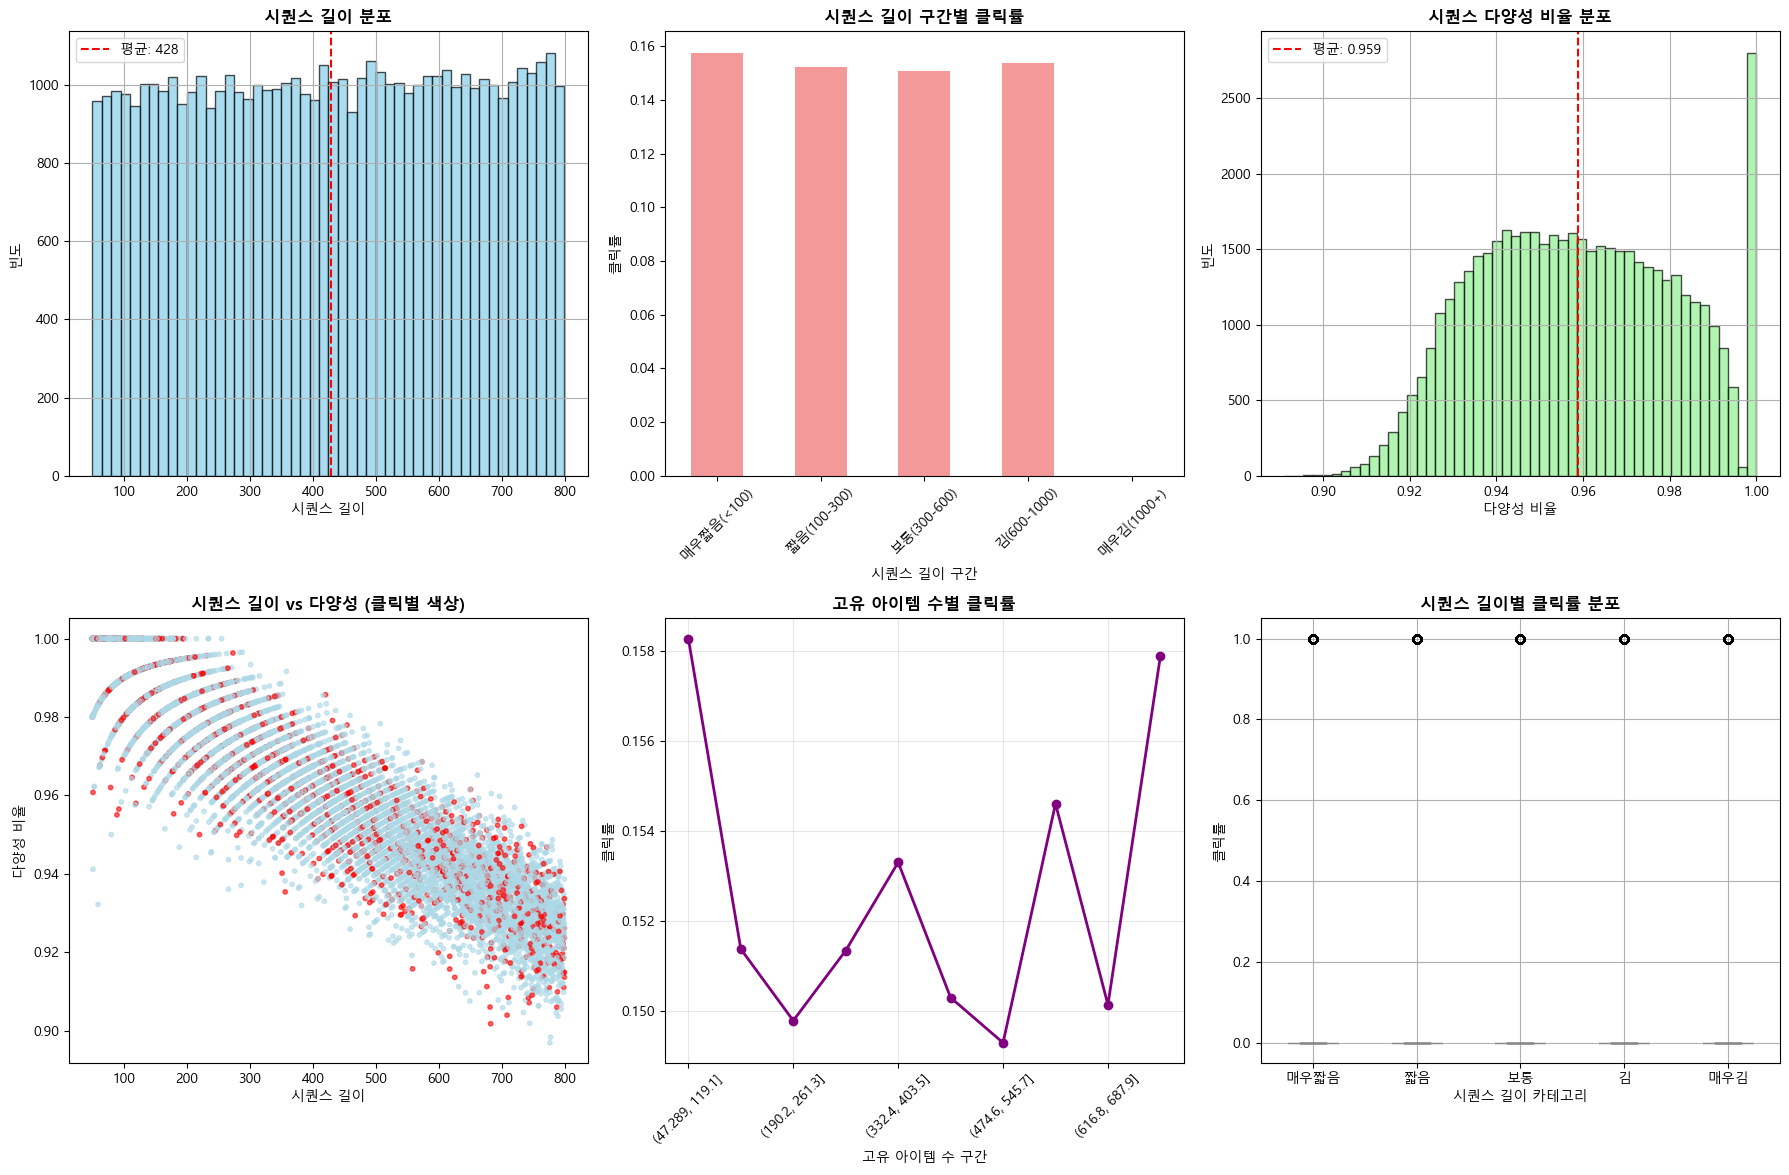

In [8]:
# 광고 클릭 예측 데이터 분석 - Part 2
# 시퀀스 분석 + 피처 상관관계 분석

import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency, pearsonr
import warnings
warnings.filterwarnings('ignore')

# # 한글 폰트 설정
# plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']
# plt.rcParams['axes.unicode_minus'] = False
# plt.style.use('default')
# sns.set_palette("husl")

print("🔍 Part 2: 시퀀스 분석 + 피처 상관관계 분석")
print("=" * 60)

# 데이터 로드
df = pd.read_parquet(PARQUET_PATH, engine='pyarrow')
for _col in ['gender', 'age_group', 'day_of_week', 'hour', 'inventory_id']:
    if _col in df.columns:
        df[_col] = pd.to_numeric(df[_col], errors='coerce')
print(f"📊 로드된 데이터: {len(df):,} 샘플")

# ========================================
# 🔗 1. 시퀀스 데이터 (seq) 분석
# ========================================

print("\n" + "="*60)
print("🔗 시퀀스 데이터 (seq) 분석")
print("="*60)

# 시퀀스 길이 분석
df['seq_length'] = df['seq'].str.split(',').str.len()
df['seq_items'] = df['seq'].str.split(',')

print("📏 시퀀스 길이 통계:")
seq_stats = df['seq_length'].describe()
print(seq_stats)

# 시퀀스 길이별 클릭률 분석
seq_length_analysis = df.groupby('seq_length').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
seq_length_analysis.columns = ['샘플수', '클릭수', '클릭률']

print(f"\n📊 시퀀스 길이별 클릭률 (상위 10개):")
print(seq_length_analysis.sort_values('클릭률', ascending=False).head(10))

# 시퀀스 길이 구간별 분석
df['seq_length_bin'] = pd.cut(df['seq_length'], 
                             bins=[0, 100, 300, 600, 1000, float('inf')], 
                             labels=['매우짧음(<100)', '짧음(100-300)', '보통(300-600)', '김(600-1000)', '매우김(1000+)'])

seq_bin_analysis = df.groupby('seq_length_bin').agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
seq_bin_analysis.columns = ['샘플수', '클릭수', '클릭률']

print(f"\n📊 시퀀스 길이 구간별 분석:")
print(seq_bin_analysis)

# 시퀀스 내 고유 아이템 수 분석
def count_unique_items(seq_str):
    try:
        items = seq_str.split(',')
        return len(set(items))
    except:
        return 0

df['unique_items'] = df['seq'].apply(count_unique_items)
df['diversity_ratio'] = df['unique_items'] / df['seq_length']

print(f"\n🌈 시퀀스 다양성 분석:")
print(f"   평균 고유 아이템 수: {df['unique_items'].mean():.2f}")
print(f"   평균 다양성 비율: {df['diversity_ratio'].mean():.4f}")

diversity_analysis = df.groupby(pd.cut(df['diversity_ratio'], bins=5)).agg({
    'clicked': ['count', 'mean']
}).round(4)
diversity_analysis.columns = ['샘플수', '클릭률']
print(f"\n📊 다양성 비율별 클릭률:")
print(diversity_analysis)

# 시퀀스 분석 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 시퀀스 길이 분포
df['seq_length'].hist(bins=50, ax=axes[0,0], color='skyblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('시퀀스 길이 분포', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('시퀀스 길이')
axes[0,0].set_ylabel('빈도')
axes[0,0].axvline(df['seq_length'].mean(), color='red', linestyle='--', label=f'평균: {df["seq_length"].mean():.0f}')
axes[0,0].legend()

# 2. 시퀀스 길이 vs 클릭률 (구간별)
seq_bin_analysis['클릭률'].plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
axes[0,1].set_title('시퀀스 길이 구간별 클릭률', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('시퀀스 길이 구간')
axes[0,1].set_ylabel('클릭률')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. 다양성 비율 분포
df['diversity_ratio'].hist(bins=50, ax=axes[0,2], color='lightgreen', alpha=0.7, edgecolor='black')
axes[0,2].set_title('시퀀스 다양성 비율 분포', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('다양성 비율')
axes[0,2].set_ylabel('빈도')
axes[0,2].axvline(df['diversity_ratio'].mean(), color='red', linestyle='--', label=f'평균: {df["diversity_ratio"].mean():.3f}')
axes[0,2].legend()

# 4. 시퀀스 길이 vs 클릭률 산점도
sample_df = df.sample(n=min(10000, len(df)))  # 샘플링으로 시각화 최적화
clicked_color = sample_df['clicked'].map({0: 'lightblue', 1: 'red'})
axes[1,0].scatter(sample_df['seq_length'], sample_df['diversity_ratio'], 
                  c=clicked_color, alpha=0.6, s=10)
axes[1,0].set_title('시퀀스 길이 vs 다양성 (클릭별 색상)', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('시퀀스 길이')
axes[1,0].set_ylabel('다양성 비율')

# 5. 고유 아이템 수 vs 클릭률
unique_bins = pd.cut(df['unique_items'], bins=10)
unique_analysis = df.groupby(unique_bins)['clicked'].mean()
unique_analysis.plot(kind='line', ax=axes[1,1], marker='o', color='purple', linewidth=2)
axes[1,1].set_title('고유 아이템 수별 클릭률', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('고유 아이템 수 구간')
axes[1,1].set_ylabel('클릭률')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3)

# 6. 시퀀스 길이와 클릭률의 관계 (박스플롯)
df['seq_length_category'] = pd.cut(df['seq_length'], bins=5, labels=['매우짧음', '짧음', '보통', '김', '매우김'])
df.boxplot(column='clicked', by='seq_length_category', ax=axes[1,2])
axes[1,2].set_title('시퀀스 길이별 클릭률 분포', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('시퀀스 길이 카테고리')
axes[1,2].set_ylabel('클릭률')

plt.suptitle('', fontsize=16)  # 기본 제목 제거
plt.tight_layout()
plt.show()



📊 피처 그룹별 분석
🔍 피처 그룹별 구성:
   l_feat: 10개 피처, 결측값: 0개
   feat_a: 5개 피처, 결측값: 0개
   feat_b: 5개 피처, 결측값: 37,335개
   feat_c: 3개 피처, 결측값: 0개
   feat_d: 3개 피처, 결측값: 0개
   feat_e: 3개 피처, 결측값: 0개
   history_a: 10개 피처, 결측값: 0개
   history_b: 30개 피처, 결측값: 0개


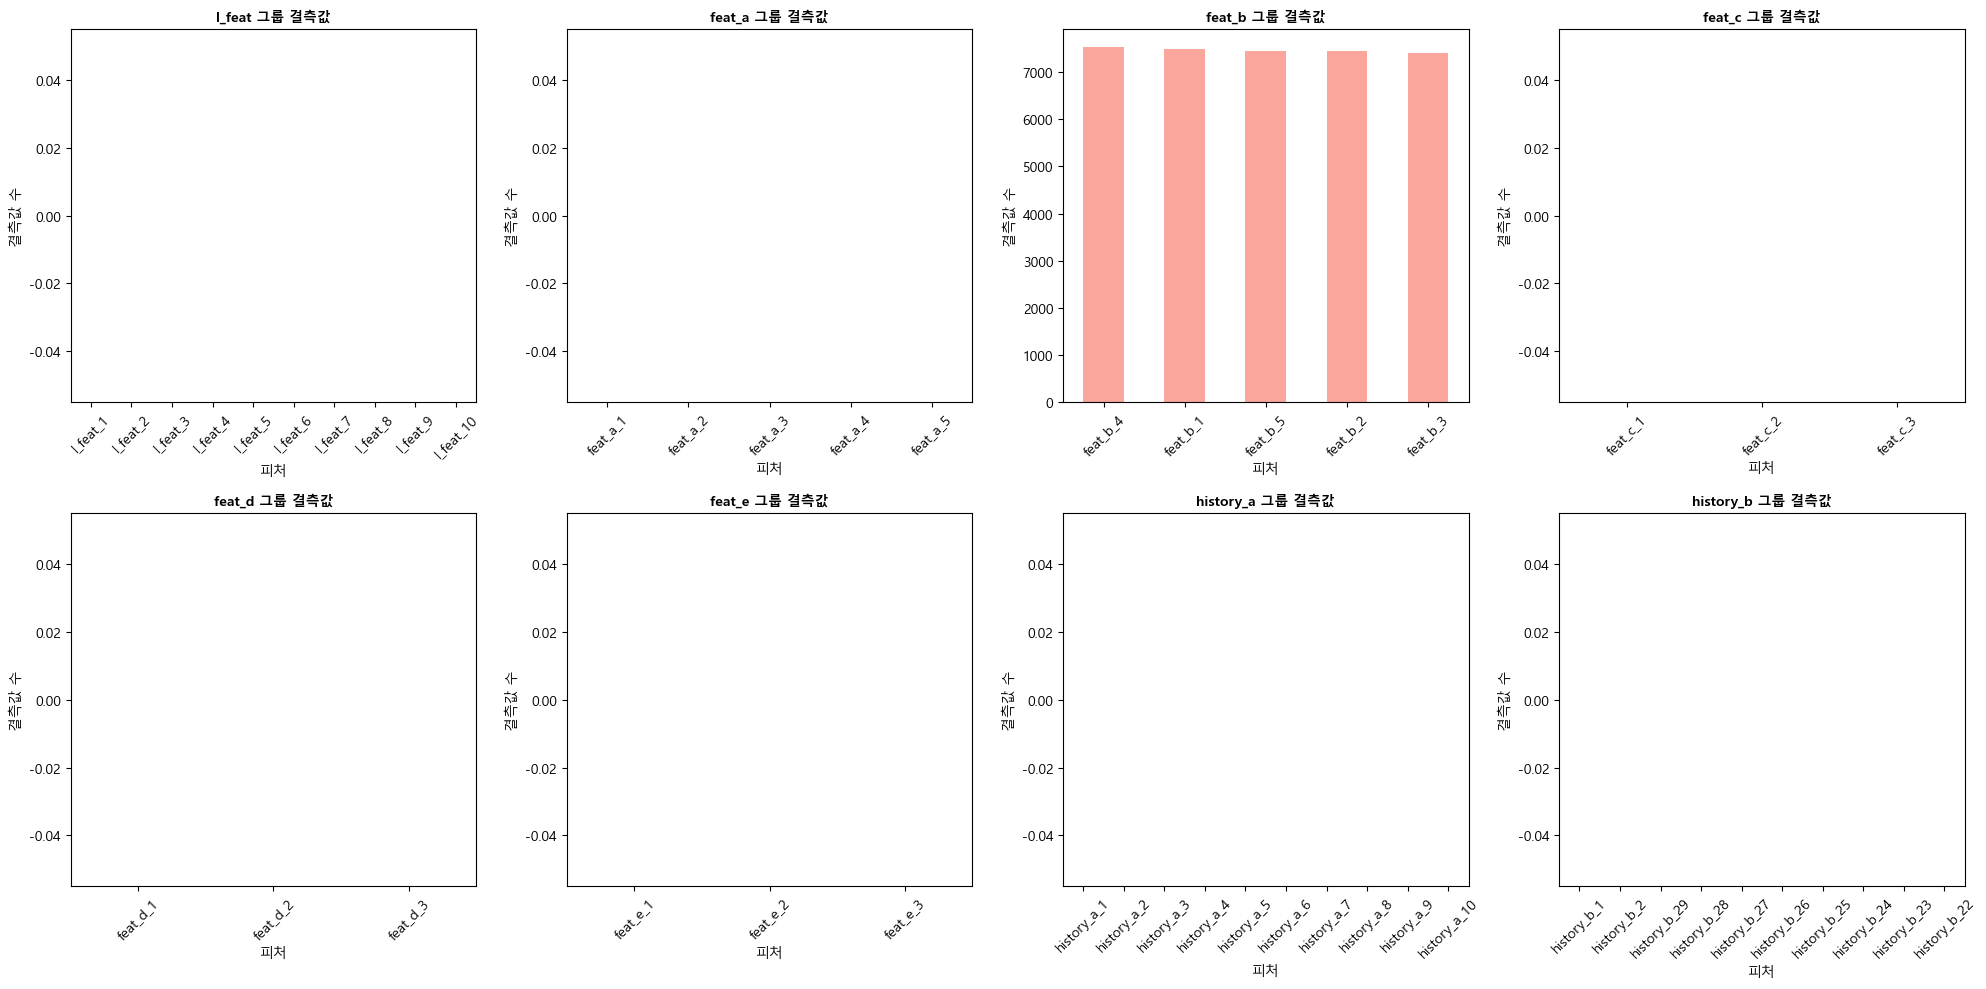

In [9]:

# ========================================
# 📊 2. 피처 그룹별 분석
# ========================================

print("\n" + "="*60)
print("📊 피처 그룹별 분석")
print("="*60)

# 피처 그룹 정의
feature_groups = {
    'l_feat': [col for col in df.columns if col.startswith('l_feat_')],
    'feat_a': [col for col in df.columns if col.startswith('feat_a_')],
    'feat_b': [col for col in df.columns if col.startswith('feat_b_')],
    'feat_c': [col for col in df.columns if col.startswith('feat_c_')],
    'feat_d': [col for col in df.columns if col.startswith('feat_d_')],
    'feat_e': [col for col in df.columns if col.startswith('feat_e_')],
    'history_a': [col for col in df.columns if col.startswith('history_a_')],
    'history_b': [col for col in df.columns if col.startswith('history_b_')]
}

print("🔍 피처 그룹별 구성:")
for group, features in feature_groups.items():
    missing_count = df[features].isnull().sum().sum()
    print(f"   {group}: {len(features)}개 피처, 결측값: {missing_count:,}개")

# 피처 그룹별 결측값 패턴 분석
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (group, features) in enumerate(feature_groups.items()):
    if i < len(axes):
        missing_pattern = df[features].isnull().sum().sort_values(ascending=False)
        if len(missing_pattern) > 0:
            missing_pattern.head(10).plot(kind='bar', ax=axes[i], color='salmon', alpha=0.7)
            axes[i].set_title(f'{group} 그룹 결측값', fontsize=10, fontweight='bold')
            axes[i].set_xlabel('피처')
            axes[i].set_ylabel('결측값 수')
            axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



🔗 타겟과 피처간 상관관계 분석
📊 타겟과 상관관계 TOP 20:
    1. history_a_1         :   0.0751 (절댓값: 0.0751)
    2. age_group           :  -0.0564 (절댓값: 0.0564)
    3. hour                :   0.0359 (절댓값: 0.0359)
    4. l_feat_8            :  -0.0092 (절댓값: 0.0092)
    5. l_feat_5            :   0.0089 (절댓값: 0.0089)
    6. history_a_10        :   0.0085 (절댓값: 0.0085)
    7. feat_e_2            :   0.0083 (절댓값: 0.0083)
    8. feat_a_1            :   0.0076 (절댓값: 0.0076)
    9. l_feat_7            :  -0.0076 (절댓값: 0.0076)
   10. l_feat_3            :   0.0072 (절댓값: 0.0072)
   11. feat_a_5            :  -0.0071 (절댓값: 0.0071)
   12. day_of_week         :   0.0068 (절댓값: 0.0068)
   13. history_b_2         :  -0.0060 (절댓값: 0.0060)
   14. feat_b_2            :   0.0060 (절댓값: 0.0060)
   15. feat_a_2            :  -0.0059 (절댓값: 0.0059)
   16. history_a_4         :   0.0055 (절댓값: 0.0055)
   17. history_b_12        :  -0.0054 (절댓값: 0.0054)
   18. history_b_10        :   0.0053 (절댓값: 0.0053)
   19. history_a_8        

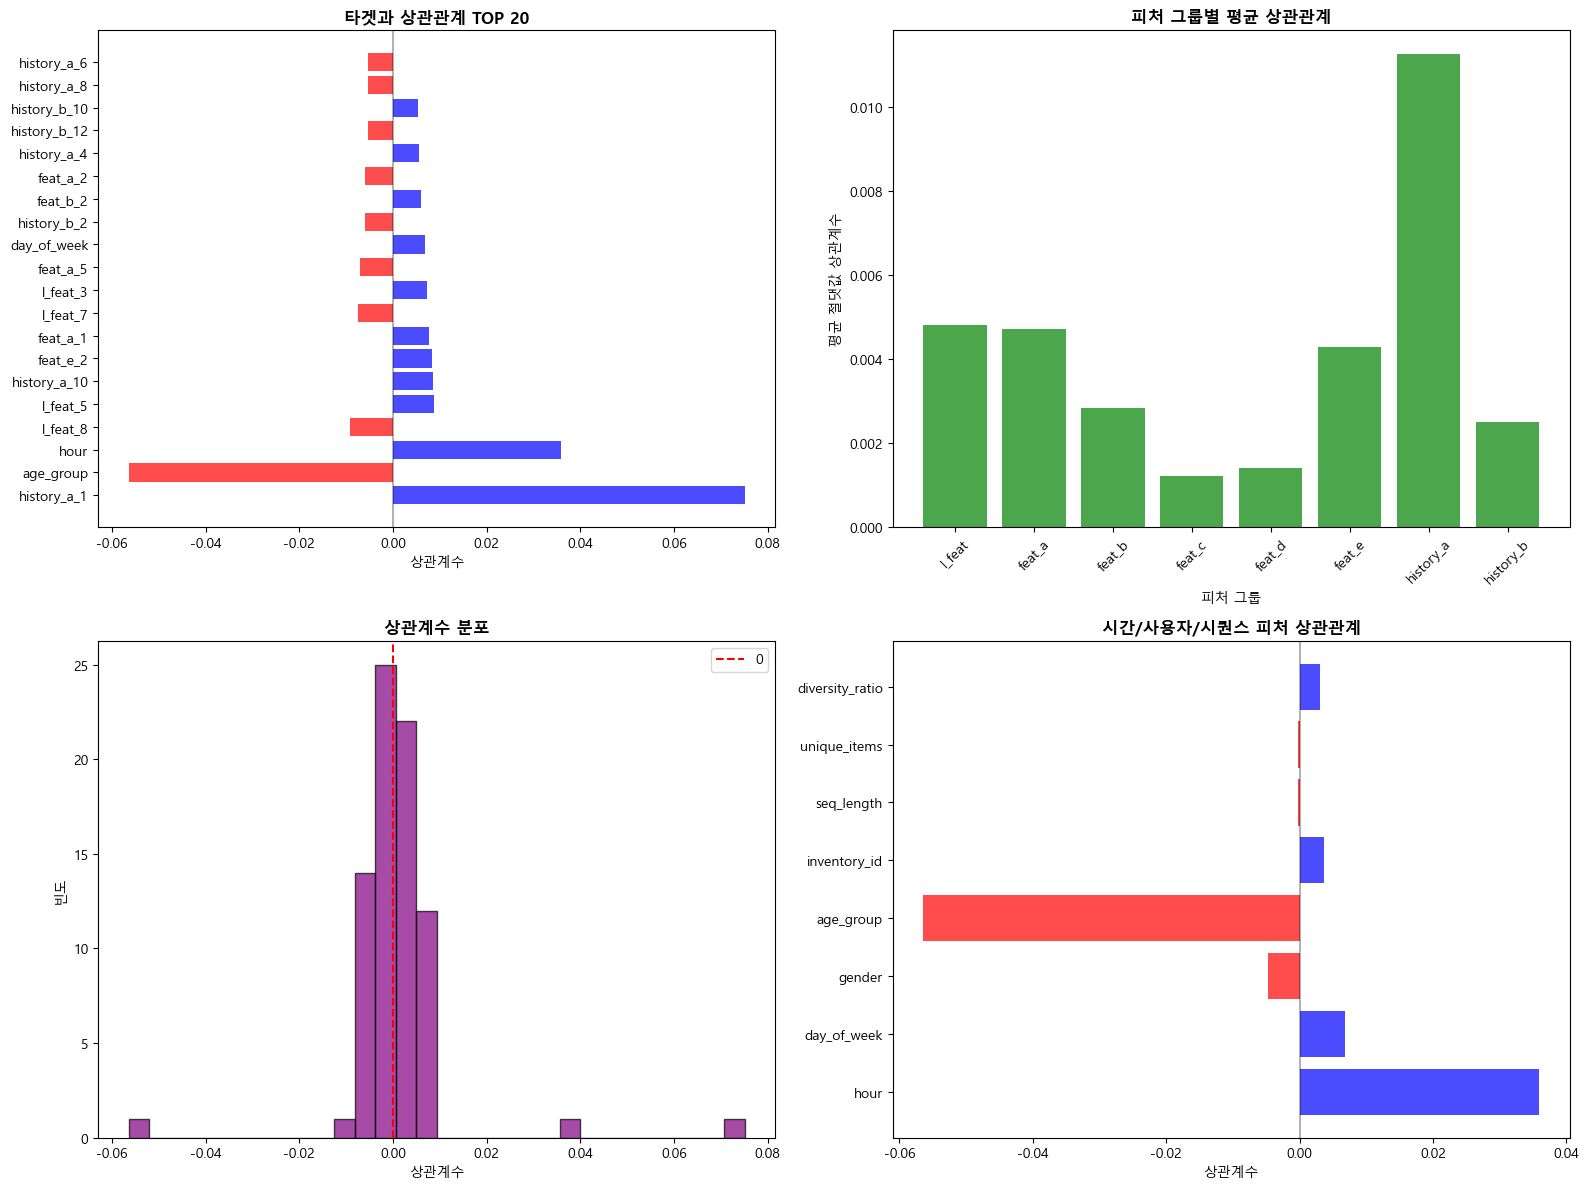

In [10]:

# ========================================
# 🔗 3. 타겟과 피처간 상관관계 분석
# ========================================

print("\n" + "="*60)
print("🔗 타겟과 피처간 상관관계 분석")
print("="*60)

# 수치형 피처들과 타겟의 상관관계
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'clicked']

# 상관관계 계산 (결측값 처리)
correlations = []
for feature in numeric_features:
    if df[feature].notna().sum() > 100:  # 충분한 데이터가 있는 경우만
        corr = df[['clicked', feature]].corr().iloc[0, 1]
        if not np.isnan(corr):
            correlations.append((feature, abs(corr), corr))

correlations.sort(key=lambda x: x[1], reverse=True)

print("📊 타겟과 상관관계 TOP 20:")
for i, (feature, abs_corr, corr) in enumerate(correlations[:20]):
    print(f"   {i+1:2d}. {feature:20s}: {corr:8.4f} (절댓값: {abs_corr:.4f})")

# 상관관계 시각화
top_features = [item[0] for item in correlations[:20]]
corr_values = [item[2] for item in correlations[:20]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 상위 20개 피처의 상관관계
axes[0,0].barh(range(len(top_features)), corr_values, color=['red' if x < 0 else 'blue' for x in corr_values], alpha=0.7)
axes[0,0].set_yticks(range(len(top_features)))
axes[0,0].set_yticklabels(top_features)
axes[0,0].set_title('타겟과 상관관계 TOP 20', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('상관계수')
axes[0,0].axvline(0, color='black', linestyle='-', alpha=0.3)

# 2. 피처 그룹별 평균 상관관계
group_correlations = {}
for group, features in feature_groups.items():
    group_corrs = []
    for feature in features:
        if feature in [item[0] for item in correlations]:
            corr_val = next(item[2] for item in correlations if item[0] == feature)
            group_corrs.append(abs(corr_val))
    if group_corrs:
        group_correlations[group] = np.mean(group_corrs)

if group_correlations:
    groups = list(group_correlations.keys())
    values = list(group_correlations.values())
    axes[0,1].bar(groups, values, color='green', alpha=0.7)
    axes[0,1].set_title('피처 그룹별 평균 상관관계', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('피처 그룹')
    axes[0,1].set_ylabel('평균 절댓값 상관계수')
    axes[0,1].tick_params(axis='x', rotation=45)

# 3. 상관관계 분포
all_corr_values = [item[2] for item in correlations]
axes[1,0].hist(all_corr_values, bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1,0].set_title('상관계수 분포', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('상관계수')
axes[1,0].set_ylabel('빈도')
axes[1,0].axvline(0, color='red', linestyle='--', label='0')
axes[1,0].legend()

# 4. 시간/사용자 피처와의 상관관계
time_user_features = ['hour', 'day_of_week', 'gender', 'age_group', 'inventory_id', 'seq_length', 'unique_items', 'diversity_ratio']
time_user_corrs = []
time_user_names = []

for feature in time_user_features:
    if feature in df.columns:
        corr = df[['clicked', feature]].corr().iloc[0, 1]
        if not np.isnan(corr):
            time_user_corrs.append(corr)
            time_user_names.append(feature)

if time_user_corrs:
    axes[1,1].barh(range(len(time_user_names)), time_user_corrs, 
                   color=['red' if x < 0 else 'blue' for x in time_user_corrs], alpha=0.7)
    axes[1,1].set_yticks(range(len(time_user_names)))
    axes[1,1].set_yticklabels(time_user_names)
    axes[1,1].set_title('시간/사용자/시퀀스 피처 상관관계', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('상관계수')
    axes[1,1].axvline(0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:

# ========================================
# 🔥 4. 피처 중요도 분석 (간단한 통계적 방법)
# ========================================

print("\n" + "="*60)
print("🔥 피처 중요도 분석")
print("="*60)

# 범주형 피처의 카이제곱 검정
categorical_features = ['gender', 'age_group', 'day_of_week', 'hour', 'inventory_id']
chi2_results = []

for feature in categorical_features:
    if feature in df.columns:
        # 결측값 제거
        temp_df = df[[feature, 'clicked']].dropna()
        if len(temp_df) > 0:
            contingency = pd.crosstab(temp_df[feature], temp_df['clicked'])
            if contingency.shape[0] > 1 and contingency.shape[1] > 1:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                chi2_results.append((feature, chi2, p_value))

chi2_results.sort(key=lambda x: x[1], reverse=True)

print("📊 범주형 피처 카이제곱 검정 결과:")
for feature, chi2_stat, p_val in chi2_results:
    significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"   {feature:15s}: χ² = {chi2_stat:10.2f}, p-value = {p_val:.6f} {significance}")

# 수치형 피처의 평균 차이 분석
print(f"\n📊 수치형 피처 클릭/비클릭 평균 차이 (TOP 15):")
feature_diffs = []

for feature in top_features[:15]:  # 상관관계 높은 피처들만
    clicked_mean = df[df['clicked'] == 1][feature].mean()
    not_clicked_mean = df[df['clicked'] == 0][feature].mean()
    diff = clicked_mean - not_clicked_mean
    feature_diffs.append((feature, clicked_mean, not_clicked_mean, diff))

feature_diffs.sort(key=lambda x: abs(x[3]), reverse=True)

for feature, click_mean, no_click_mean, diff in feature_diffs:
    print(f"   {feature:20s}: 클릭 {click_mean:8.4f} vs 비클릭 {no_click_mean:8.4f} (차이: {diff:8.4f})")



🔥 피처 중요도 분석
📊 범주형 피처 카이제곱 검정 결과:
   hour           : χ² =     408.62, p-value = 0.000000 ***
   age_group      : χ² =     182.93, p-value = 0.000000 ***
   inventory_id   : χ² =      41.14, p-value = 0.779999 
   day_of_week    : χ² =       7.20, p-value = 0.302734 
   gender         : χ² =       1.37, p-value = 0.505213 

📊 수치형 피처 클릭/비클릭 평균 차이 (TOP 15):
   history_a_1         : 클릭   5.9153 vs 비클릭   4.8635 (차이:   1.0518)
   hour                : 클릭  12.1625 vs 비클릭  11.4721 (차이:   0.6904)
   age_group           : 클릭   2.2669 vs 비클릭   2.5345 (차이:  -0.2676)
   history_a_10        : 클릭   5.1036 vs 비클릭   4.9847 (차이:   0.1189)
   history_b_2         : 클릭   2.9814 vs 비클릭   3.0322 (차이:  -0.0508)
   day_of_week         : 클릭   3.0287 vs 비클릭   2.9909 (차이:   0.0378)
   l_feat_8            : 클릭  -0.0128 vs 비클릭   0.0130 (차이:  -0.0258)
   l_feat_5            : 클릭   0.0156 vs 비클릭  -0.0091 (차이:   0.0247)
   feat_e_2            : 클릭   0.0153 vs 비클릭  -0.0079 (차이:   0.0232)
   feat_a_1            : 클릭   

🚀 Part 3: 고급 분석 - PCA/클러스터링 + 심화 인사이트
📊 로드된 데이터: 50,000 샘플

🔍 피처 상호작용 심화 분석
📊 inventory_id x 시간대 상호작용:
최고 성과 조합 (inventory_id x hour):
                   샘플수  클릭수     클릭률
inventory_id hour                  
3            15    105   31  0.2952
1            13    119   35  0.2941
6            14     94   26  0.2766
8            18     74   19  0.2568
9            17     71   18  0.2535
7            13     87   22  0.2529
3            13    103   26  0.2524
4            17    120   30  0.2500
0            16    137   34  0.2482
1            16    121   30  0.2479

📊 연령그룹 x 다양성 비율 상호작용:
                          샘플수     클릭률
age_group diversity_bin              
1         낮음              184  0.2011
0         낮음              166  0.1867
1         보통             2532  0.1848
          높음             3122  0.1794
          매우높음           2514  0.1762
2         매우높음           2533  0.1737
0         매우높음           2389  0.1720
          높음             3312  0.1709
2         높음             3230 

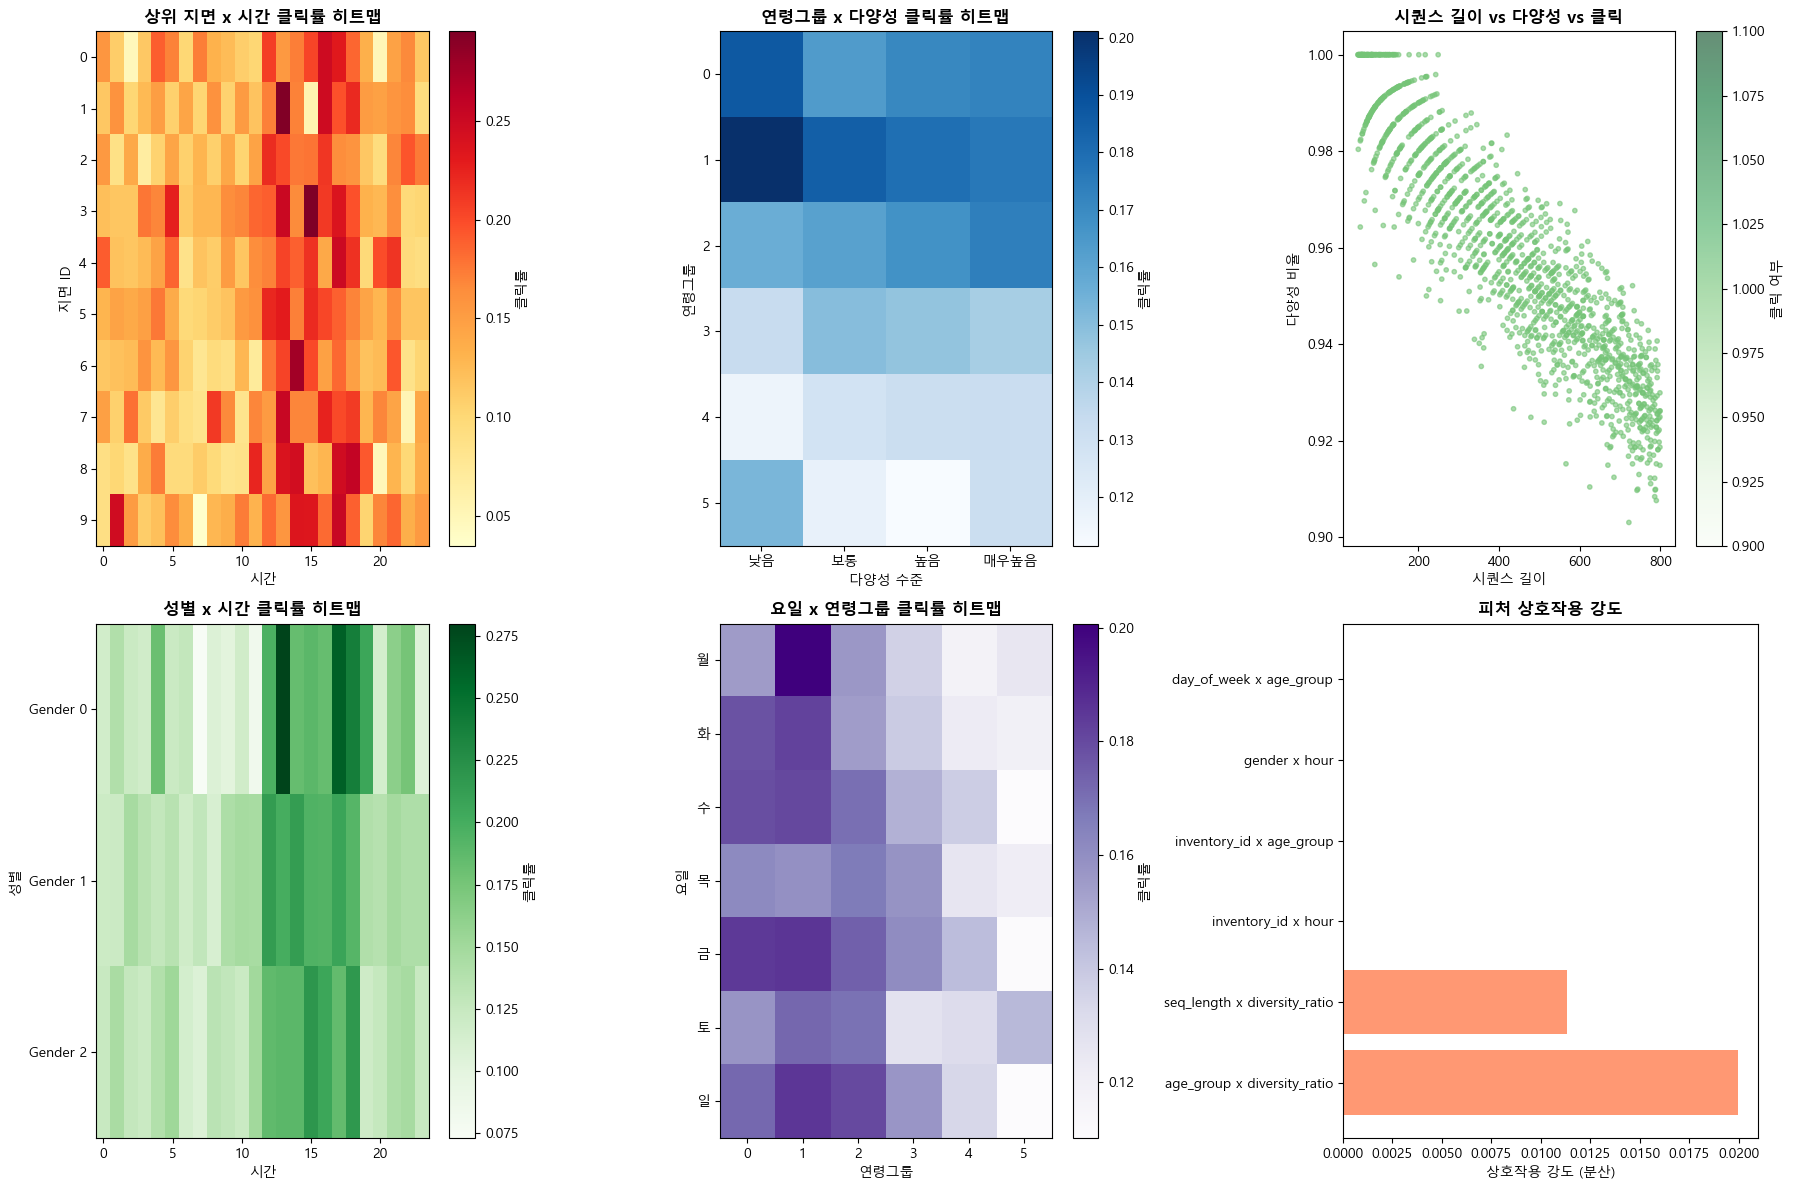

In [12]:
# 광고 클릭 예측 데이터 분석 - Part 3
# 고급 분석: PCA/클러스터링 + 심화 인사이트 + 인터랙티브 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# # 한글 폰트 설정
# plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'Malgun Gothic']
# plt.rcParams['axes.unicode_minus'] = False
# plt.style.use('default')
# sns.set_palette("husl")

print("🚀 Part 3: 고급 분석 - PCA/클러스터링 + 심화 인사이트")
print("=" * 70)

# 데이터 로드
df = pd.read_parquet(PARQUET_PATH, engine='pyarrow')
for _col in ['gender', 'age_group', 'day_of_week', 'hour', 'inventory_id']:
    if _col in df.columns:
        df[_col] = pd.to_numeric(df[_col], errors='coerce')

# 시퀀스 분석 결과 재생성 (Part 2에서 생성한 피처들)
df['seq_length'] = df['seq'].str.split(',').str.len()
def count_unique_items(seq_str):
    try:
        items = seq_str.split(',')
        return len(set(items))
    except:
        return 0

df['unique_items'] = df['seq'].apply(count_unique_items)
df['diversity_ratio'] = df['unique_items'] / df['seq_length']

print(f"📊 로드된 데이터: {len(df):,} 샘플")

# ========================================
# 🔍 1. 피처 상호작용 심화 분석
# ========================================

print("\n" + "="*70)
print("🔍 피처 상호작용 심화 분석")
print("="*70)

# 핵심 피처들 정의 (Part 2 결과 기반)
top_features = [
    'history_a_1', 'history_a_2', 'history_b_2', 'history_a_3', 'history_b_30',
    'history_a_5', 'history_b_1', 'inventory_id', 'feat_b_4', 'history_b_10'
]

# 시간 + 사용자 + 시퀀스 피처
context_features = ['hour', 'day_of_week', 'gender', 'age_group', 'seq_length', 'diversity_ratio']

# 상호작용 분석: inventory_id x 시간대
print("📊 inventory_id x 시간대 상호작용:")
inv_hour_analysis = df.groupby(['inventory_id', 'hour']).agg({
    'clicked': ['count', 'sum', 'mean']
}).round(4)
inv_hour_analysis.columns = ['샘플수', '클릭수', '클릭률']

# 상위 inventory_id들만 분석
top_inventories = df['inventory_id'].value_counts().head(10).index
inv_hour_filtered = inv_hour_analysis.loc[top_inventories]
best_combinations = inv_hour_filtered.sort_values('클릭률', ascending=False).head(10)
print("최고 성과 조합 (inventory_id x hour):")
print(best_combinations)

# 연령그룹 x 다양성 비율 상호작용
print(f"\n📊 연령그룹 x 다양성 비율 상호작용:")
df['diversity_bin'] = pd.cut(df['diversity_ratio'], bins=4, labels=['낮음', '보통', '높음', '매우높음'])
age_diversity_analysis = df.groupby(['age_group', 'diversity_bin']).agg({
    'clicked': ['count', 'mean']
}).round(4)
age_diversity_analysis.columns = ['샘플수', '클릭률']
print(age_diversity_analysis.sort_values('클릭률', ascending=False).head(10))

# 상호작용 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. inventory_id TOP 10의 시간별 클릭률 히트맵
top_inv_hour = df[df['inventory_id'].isin(top_inventories)]
pivot_inv_hour = top_inv_hour.groupby(['inventory_id', 'hour'])['clicked'].mean().unstack(fill_value=0)
im1 = axes[0,0].imshow(pivot_inv_hour.values, cmap='YlOrRd', aspect='auto')
axes[0,0].set_title('상위 지면 x 시간 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('시간')
axes[0,0].set_ylabel('지면 ID')
axes[0,0].set_yticks(range(len(pivot_inv_hour.index)))
axes[0,0].set_yticklabels(pivot_inv_hour.index)
plt.colorbar(im1, ax=axes[0,0], label='클릭률')

# 2. 연령그룹 x 다양성 히트맵
pivot_age_div = df.groupby(['age_group', 'diversity_bin'])['clicked'].mean().unstack(fill_value=0)
im2 = axes[0,1].imshow(pivot_age_div.values, cmap='Blues', aspect='auto')
axes[0,1].set_title('연령그룹 x 다양성 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('다양성 수준')
axes[0,1].set_ylabel('연령그룹')
axes[0,1].set_yticks(range(len(pivot_age_div.index)))
axes[0,1].set_yticklabels(pivot_age_div.index)
axes[0,1].set_xticks(range(len(pivot_age_div.columns)))
axes[0,1].set_xticklabels(pivot_age_div.columns)
plt.colorbar(im2, ax=axes[0,1], label='클릭률')

# 3. 시퀀스 길이 vs 다양성 vs 클릭률 (3D 스타일)
sample_df = df.sample(n=10000)  # 샘플링
sample_df = sample_df[sample_df['clicked'] == 1]
scatter = axes[0,2].scatter(sample_df['seq_length'], sample_df['diversity_ratio'], 
                           c=sample_df['clicked'], cmap='Greens', alpha=0.6, s=10)
axes[0,2].set_title('시퀀스 길이 vs 다양성 vs 클릭', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('시퀀스 길이')
axes[0,2].set_ylabel('다양성 비율')
plt.colorbar(scatter, ax=axes[0,2], label='클릭 여부')

# 4. 성별 x 시간 x 클릭률
pivot_gender_hour = df.groupby(['gender', 'hour'])['clicked'].mean().unstack(fill_value=0)
im3 = axes[1,0].imshow(pivot_gender_hour.values, cmap='Greens', aspect='auto')
axes[1,0].set_title('성별 x 시간 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('시간')
axes[1,0].set_ylabel('성별')
axes[1,0].set_yticks(range(len(pivot_gender_hour.index)))
axes[1,0].set_yticklabels([f'Gender {int(x)}' for x in pivot_gender_hour.index])
plt.colorbar(im3, ax=axes[1,0], label='클릭률')

# 5. 요일 x 연령그룹 패턴
pivot_day_age = df.groupby(['day_of_week', 'age_group'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1,1].imshow(pivot_day_age.values, cmap='Purples', aspect='auto')
axes[1,1].set_title('요일 x 연령그룹 클릭률 히트맵', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('연령그룹')
axes[1,1].set_ylabel('요일')
day_names = ['월', '화', '수', '목', '금', '토', '일']
axes[1,1].set_yticks(range(len(pivot_day_age.index)))
axes[1,1].set_yticklabels([day_names[i] if i < len(day_names) else f'Day_{i}' for i in pivot_day_age.index])
plt.colorbar(im4, ax=axes[1,1], label='클릭률')

# 6. 종합 상호작용 강도 분석
interaction_strength = []
feature_pairs = [
    ('inventory_id', 'hour'), ('age_group', 'diversity_ratio'), 
    ('gender', 'hour'), ('day_of_week', 'age_group'),
    ('inventory_id', 'age_group'), ('seq_length', 'diversity_ratio')
]

for feat1, feat2 in feature_pairs:
    if feat1 in df.columns and feat2 in df.columns:
        cross_tab = pd.crosstab(df[feat1], df[feat2], df['clicked'], aggfunc='mean')
        variance = cross_tab.var().var() if not cross_tab.empty else 0
        interaction_strength.append((f'{feat1} x {feat2}', variance))

interaction_strength.sort(key=lambda x: x[1], reverse=True)
features_names = [item[0] for item in interaction_strength]
strengths = [item[1] for item in interaction_strength]

axes[1,2].barh(range(len(features_names)), strengths, color='coral', alpha=0.8)
axes[1,2].set_yticks(range(len(features_names)))
axes[1,2].set_yticklabels(features_names)
axes[1,2].set_title('피처 상호작용 강도', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('상호작용 강도 (분산)')

plt.tight_layout()
plt.show()



🎯 PCA 차원축소 및 패턴 발견
📊 PCA 분석 결과:
   95% 분산 설명하는 성분 수: 72
   90% 분산 설명하는 성분 수: 67
   처음 10개 성분의 분산 설명율: 0.1613

🔍 PC1 (제1주성분) 주요 기여 피처 TOP 10:
            feature  importance
74       seq_length    0.584305
75     unique_items    0.582730
76  diversity_ratio    0.563979
25         feat_c_1    0.008816
0              hour    0.008145
26         feat_c_2    0.007853
13         l_feat_9    0.006894
34      history_a_1    0.006607
57     history_b_14    0.006558
35      history_a_2    0.006219

🔍 PC2 (제2주성분) 주요 기여 피처 TOP 10:
         feature  importance
35   history_a_2    0.298840
68  history_b_25    0.255617
10      l_feat_6    0.240305
11      l_feat_7    0.224558
44   history_b_1    0.218294
64  history_b_21    0.206864
51   history_b_8    0.203330
21      feat_b_2    0.193590
48   history_b_5    0.192971
0           hour    0.181631


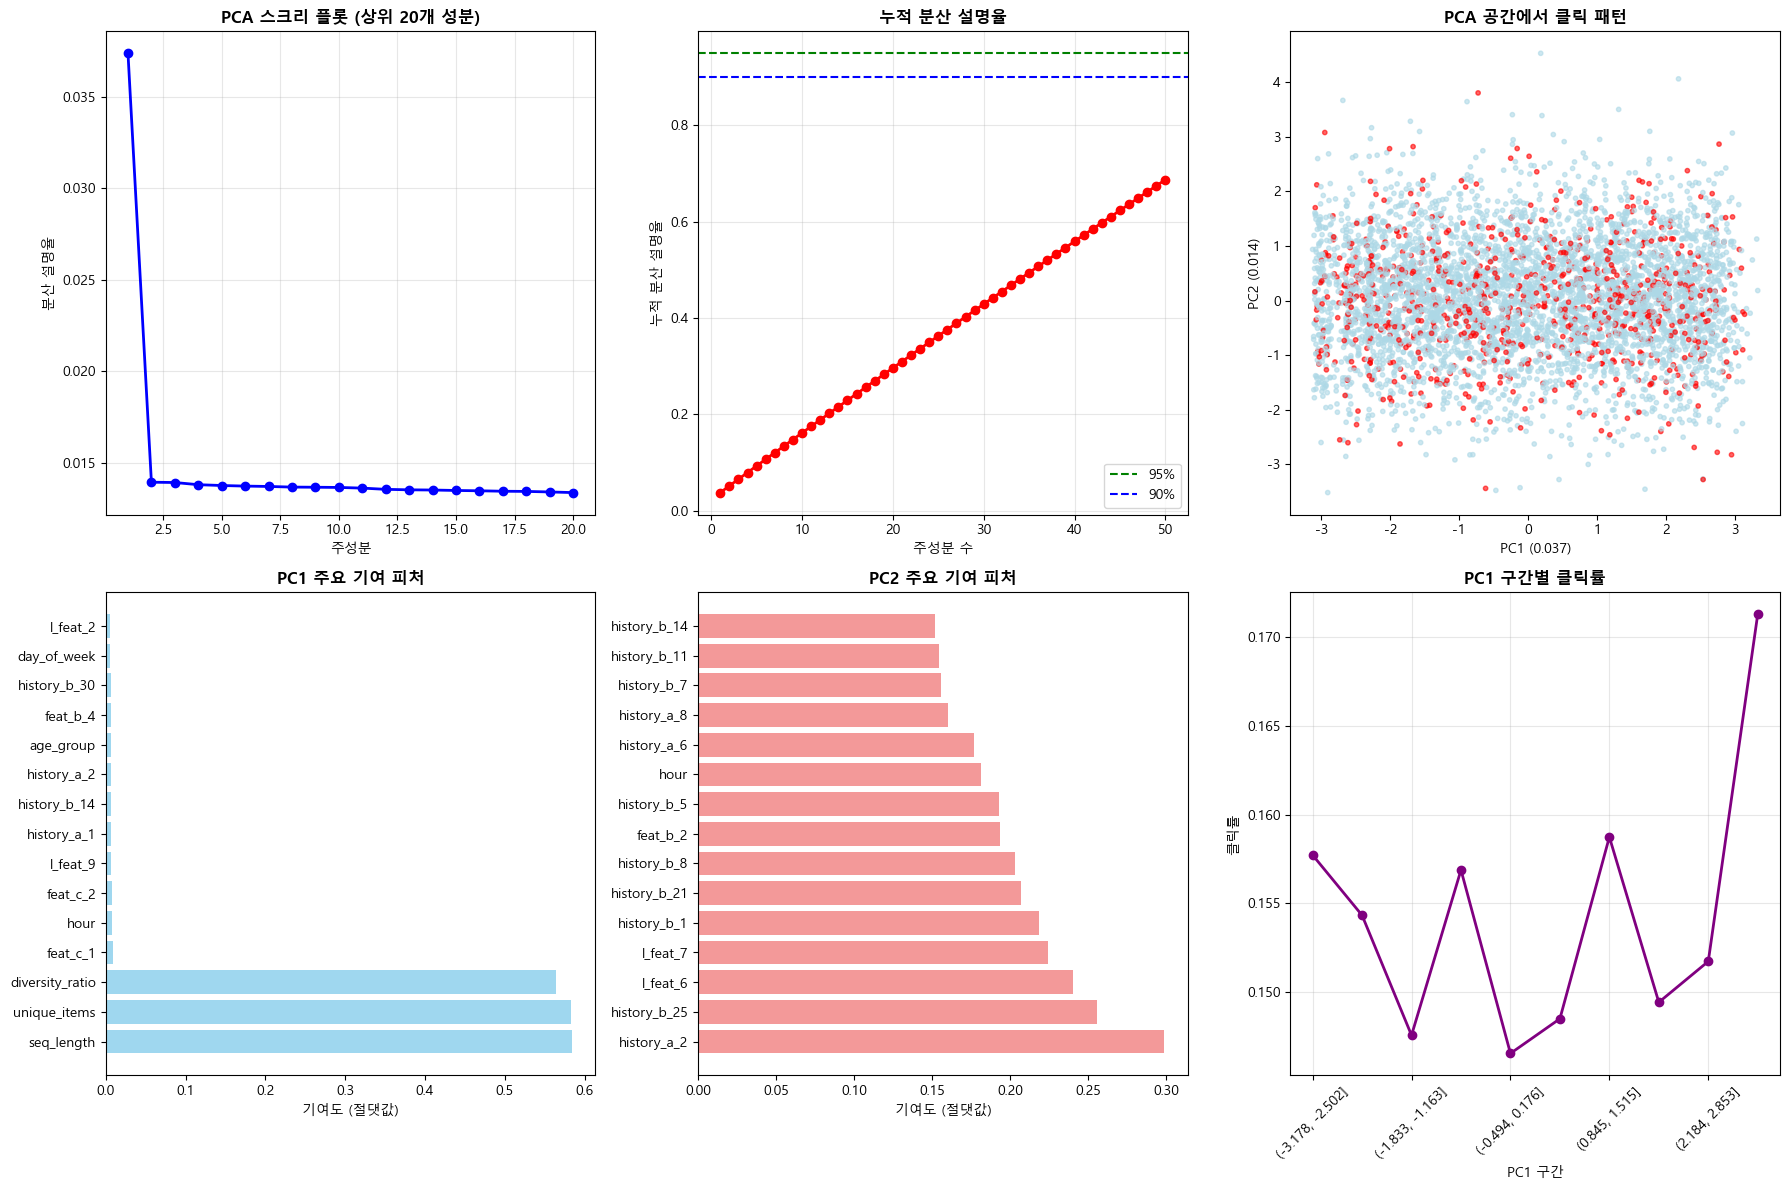

In [13]:

# ========================================
# 🎯 2. PCA 차원축소 및 패턴 발견
# ========================================

print("\n" + "="*70)
print("🎯 PCA 차원축소 및 패턴 발견")
print("="*70)

# 수치형 피처만 선택하고 결측값 처리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['clicked']]

# PCA를 위한 데이터 준비
pca_data = df[numeric_cols].fillna(df[numeric_cols].median())
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# PCA 수행
pca = PCA()
pca_result = pca.fit_transform(pca_data_scaled)

# 누적 분산 비율 계산
cumsum_var_ratio = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum_var_ratio >= 0.95) + 1
n_components_90 = np.argmax(cumsum_var_ratio >= 0.90) + 1

print(f"📊 PCA 분석 결과:")
print(f"   95% 분산 설명하는 성분 수: {n_components_95}")
print(f"   90% 분산 설명하는 성분 수: {n_components_90}")
print(f"   처음 10개 성분의 분산 설명율: {cumsum_var_ratio[9]:.4f}")

# 주성분별 피처 기여도 분석
feature_importance_pc1 = pd.DataFrame({
    'feature': numeric_cols,
    'importance': np.abs(pca.components_[0])
}).sort_values('importance', ascending=False)

feature_importance_pc2 = pd.DataFrame({
    'feature': numeric_cols,
    'importance': np.abs(pca.components_[1])
}).sort_values('importance', ascending=False)

print(f"\n🔍 PC1 (제1주성분) 주요 기여 피처 TOP 10:")
print(feature_importance_pc1.head(10))

print(f"\n🔍 PC2 (제2주성분) 주요 기여 피처 TOP 10:")
print(feature_importance_pc2.head(10))

# PCA 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 분산 설명율 스크리 플롯
axes[0,0].plot(range(1, 21), pca.explained_variance_ratio_[:20], 'bo-', linewidth=2)
axes[0,0].set_title('PCA 스크리 플롯 (상위 20개 성분)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('주성분')
axes[0,0].set_ylabel('분산 설명율')
axes[0,0].grid(True, alpha=0.3)

# 2. 누적 분산 설명율
axes[0,1].plot(range(1, 51), cumsum_var_ratio[:50], 'ro-', linewidth=2)
axes[0,1].axhline(y=0.95, color='green', linestyle='--', label='95%')
axes[0,1].axhline(y=0.90, color='blue', linestyle='--', label='90%')
axes[0,1].set_title('누적 분산 설명율', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('주성분 수')
axes[0,1].set_ylabel('누적 분산 설명율')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. PC1 vs PC2 산점도 (클릭별 색상)
sample_indices = np.random.choice(len(pca_result), size=5000, replace=False)
clicked_colors = df.iloc[sample_indices]['clicked'].map({0: 'lightblue', 1: 'red'})
axes[0,2].scatter(pca_result[sample_indices, 0], pca_result[sample_indices, 1], 
                  c=clicked_colors, alpha=0.6, s=10)
axes[0,2].set_title('PCA 공간에서 클릭 패턴', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
axes[0,2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')

# 4. PC1 기여도 상위 피처들
top_pc1_features = feature_importance_pc1.head(15)
axes[1,0].barh(range(len(top_pc1_features)), top_pc1_features['importance'], color='skyblue', alpha=0.8)
axes[1,0].set_yticks(range(len(top_pc1_features)))
axes[1,0].set_yticklabels(top_pc1_features['feature'])
axes[1,0].set_title('PC1 주요 기여 피처', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('기여도 (절댓값)')

# 5. PC2 기여도 상위 피처들
top_pc2_features = feature_importance_pc2.head(15)
axes[1,1].barh(range(len(top_pc2_features)), top_pc2_features['importance'], color='lightcoral', alpha=0.8)
axes[1,1].set_yticks(range(len(top_pc2_features)))
axes[1,1].set_yticklabels(top_pc2_features['feature'])
axes[1,1].set_title('PC2 주요 기여 피처', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('기여도 (절댓값)')

# 6. 주성분별 클릭률 분석
pc1_bins = pd.cut(pca_result[:, 0], bins=10)
pc1_click_rate = df.groupby(pc1_bins)['clicked'].mean()
pc1_click_rate.plot(kind='line', ax=axes[1,2], marker='o', color='purple', linewidth=2)
axes[1,2].set_title('PC1 구간별 클릭률', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('PC1 구간')
axes[1,2].set_ylabel('클릭률')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



🎨 클러스터링을 통한 사용자 세그먼트 발굴
Cluster Features :  ['hour', 'day_of_week', 'gender', 'age_group', 'inventory_id', 'l_feat_1', 'l_feat_2', 'l_feat_3', 'l_feat_4', 'l_feat_5', 'l_feat_6', 'l_feat_7', 'l_feat_8', 'l_feat_9', 'l_feat_10', 'feat_a_1', 'feat_a_2', 'feat_a_3', 'feat_a_4', 'feat_a_5', 'feat_b_1', 'feat_b_2', 'feat_b_3', 'feat_b_4', 'feat_b_5', 'feat_c_1', 'feat_c_2', 'feat_c_3', 'feat_d_1', 'feat_d_2', 'feat_d_3', 'feat_e_1', 'feat_e_2', 'feat_e_3', 'history_a_1', 'history_a_2', 'history_a_3', 'history_a_4', 'history_a_5', 'history_a_6', 'history_a_7', 'history_a_8', 'history_a_9', 'history_a_10', 'history_b_1', 'history_b_2', 'history_b_3', 'history_b_4', 'history_b_5', 'history_b_6', 'history_b_7', 'history_b_8', 'history_b_9', 'history_b_10', 'history_b_11', 'history_b_12', 'history_b_13', 'history_b_14', 'history_b_15', 'history_b_16', 'history_b_17', 'history_b_18', 'history_b_19', 'history_b_20', 'history_b_21', 'history_b_22', 'history_b_23', 'history_b_24', 'history_b_25', '

  File "c:\Users\goni1\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\goni1\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\goni1\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\goni1\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


📊 클러스터별 특성 분석:
        clicked                 hour day_of_week gender age_group seq_length  \
          count   sum   mean    mean        mean   mean      mean       mean   
cluster                                                                        
0         25713  3910  0.152  11.497       2.977  1.434     2.474    609.009   
1         24287  3714  0.153  11.663       3.018  1.425     2.514    236.226   

        diversity_ratio inventory_id  
                   mean         mean  
cluster                               
0                 0.941       12.282  
1                 0.978       12.214  

🎯 클러스터별 클릭률 랭킹:
   1. 클러스터 1: 0.1529 (15.29%)
   2. 클러스터 0: 0.1521 (15.21%)


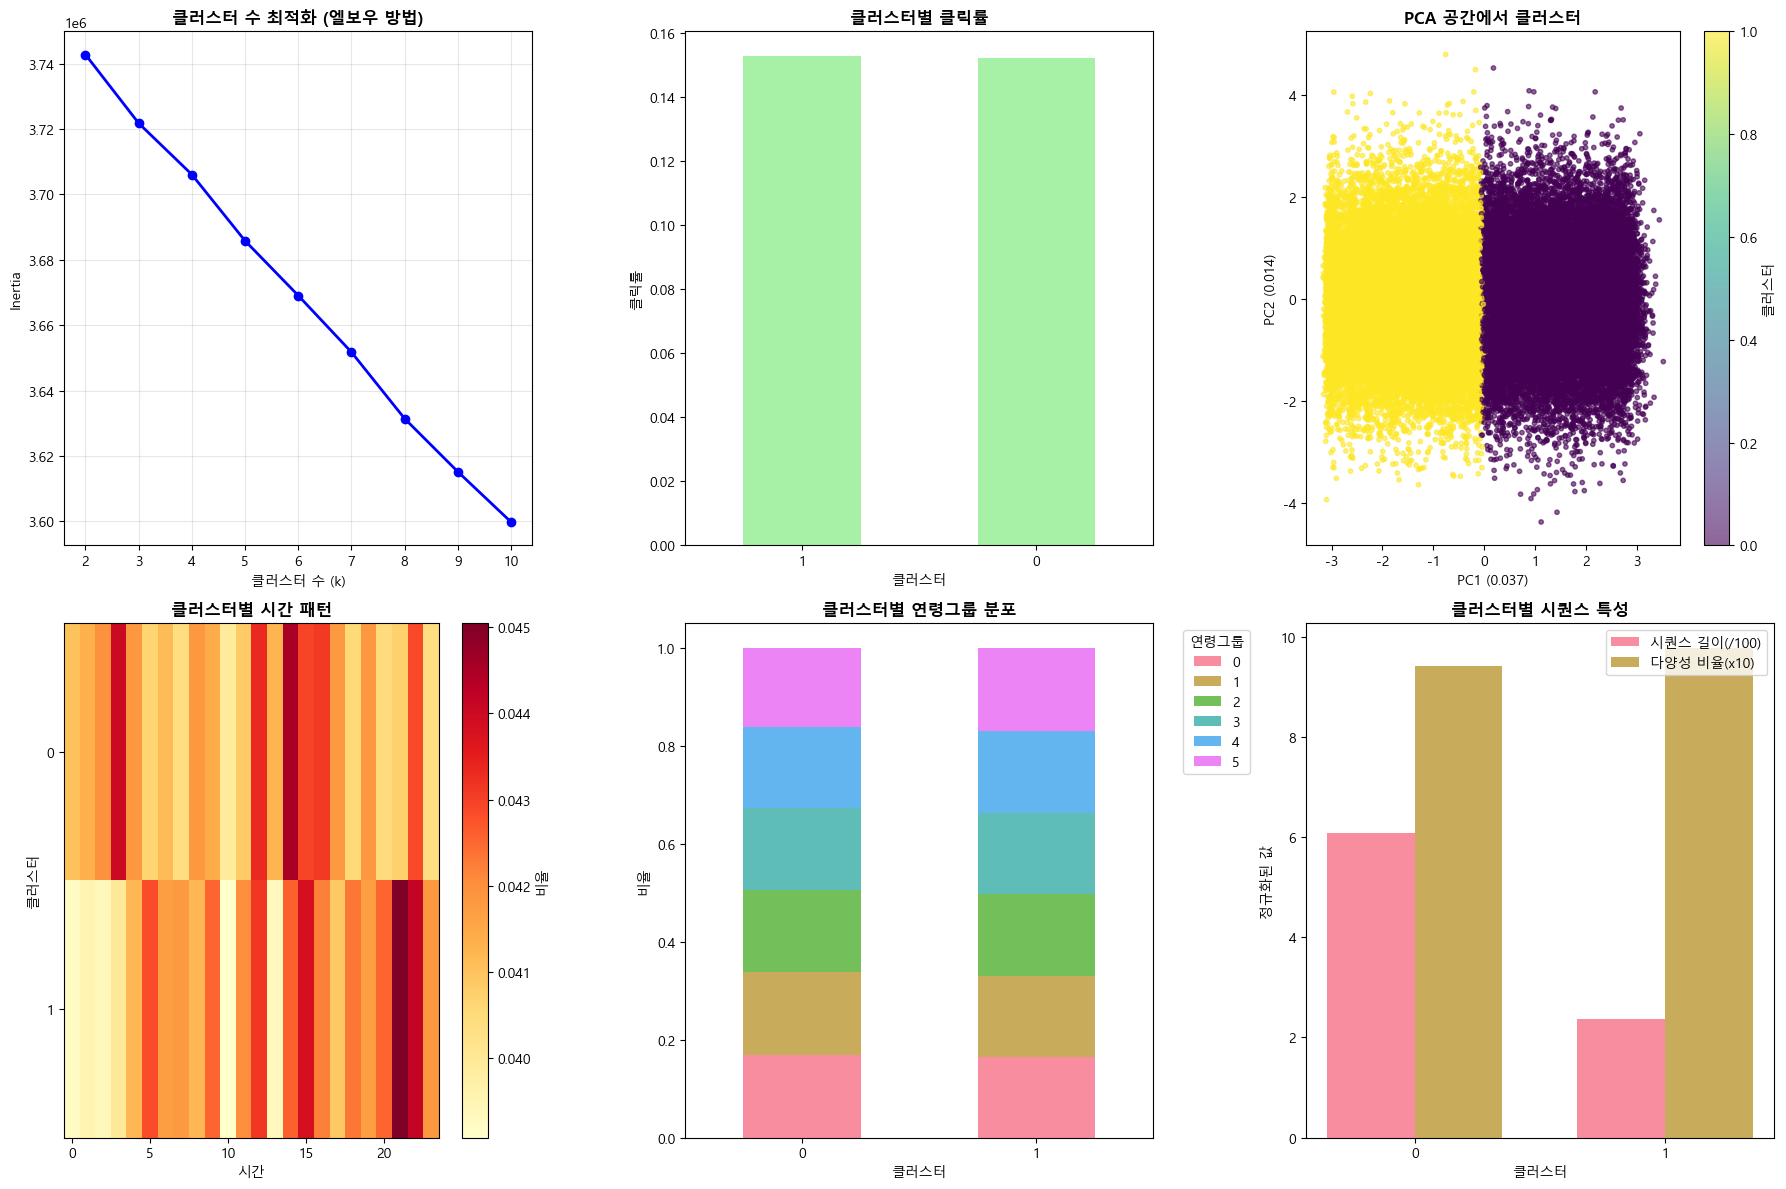

In [14]:

# ========================================
# 3. 클러스터링을 통한 사용자 세그먼트 발굴
# ========================================
import os
# Windows loky 멀티프로세싱 오류 방지
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))

print('\n' + '='*70)
print('클러스터링을 통한 사용자 세그먼트 발굴')
print('='*70)

numeric_cols = df.select_dtypes(include=[float, int]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['clicked', 'cluster']]
pca_data = df[numeric_cols].fillna(df[numeric_cols].median())
print(f'클러스터링 피처: {len(numeric_cols)}개')

scaler_cluster = StandardScaler()
clustering_data_scaled = scaler_cluster.fit_transform(pca_data)

# 엘보우 방법으로 최적 k 탐색
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clustering_data_scaled)
    inertias.append(km.inertia_)

# 최종 클러스터링 (k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(clustering_data_scaled)

# 클러스터별 특성 집계 (선택 컬럼 안전하게)
agg_dict = {
    'clicked': ['count', 'sum', 'mean'],
    'hour': 'mean', 'day_of_week': 'mean',
    'gender': 'mean', 'age_group': 'mean', 'inventory_id': 'mean',
}
for _extra in ['seq_length', 'diversity_ratio']:
    if _extra in df.columns:
        agg_dict[_extra] = 'mean'

cluster_analysis = df.groupby('cluster').agg(agg_dict).round(3)
print('\n클러스터별 특성:')
print(cluster_analysis)

cluster_click_rates = df.groupby('cluster')['clicked'].mean().sort_values(ascending=False)
print('\n클러스터별 클릭률 랭킹:')
for i, (c, r) in enumerate(cluster_click_rates.items()):
    print(f'  {i+1}. 클러스터 {c}: {r:.4f} ({r*100:.2f}%)')

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. 엘보우
axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0,0].set_title('클러스터 수 최적화 (엘보우)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia')
axes[0,0].grid(True, alpha=0.3)

# 2. 클러스터별 CTR
cluster_click_rates.plot(kind='bar', ax=axes[0,1], color='lightgreen', alpha=0.8)
axes[0,1].set_title('클러스터별 클릭률', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('클러스터'); axes[0,1].set_ylabel('CTR')
axes[0,1].tick_params(axis='x', rotation=0)

# 3. PCA 2D 산점도
pca_2d = PCA(n_components=2)
proj = pca_2d.fit_transform(clustering_data_scaled)
sc = axes[0,2].scatter(proj[:,0], proj[:,1], c=df['cluster'],
                       cmap='viridis', alpha=0.4, s=5)
axes[0,2].set_title('PCA 공간의 클러스터', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})")
axes[0,2].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})")
plt.colorbar(sc, ax=axes[0,2], label='클러스터')

# 4. 시간 패턴 히트맵
ch = df.groupby(['cluster','hour']).size().unstack(fill_value=0)
ch_norm = ch.div(ch.sum(axis=1), axis=0)
im = axes[1,0].imshow(ch_norm.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_title('클러스터별 시간 패턴', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('시간'); axes[1,0].set_ylabel('클러스터')
axes[1,0].set_yticks(range(len(ch_norm)))
axes[1,0].set_yticklabels(ch_norm.index)
plt.colorbar(im, ax=axes[1,0])

# 5. 연령그룹 분포
ca = pd.crosstab(df['cluster'], df['age_group'], normalize='index')
ca.plot(kind='bar', ax=axes[1,1], stacked=True, alpha=0.8)
axes[1,1].set_title('클러스터별 연령그룹 분포', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('클러스터'); axes[1,1].set_ylabel('비율')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='연령그룹', bbox_to_anchor=(1.05,1), loc='upper left')

# 6. seq 특성 있으면 시퀀스, 없으면 성별 분포
if 'seq_length' in df.columns and 'diversity_ratio' in df.columns:
    import numpy as _np
    css = df.groupby('cluster')[['seq_length','diversity_ratio']].mean()
    x_ = _np.arange(len(css))
    axes[1,2].bar(x_-0.2, css['seq_length']/100, 0.35, label='시퀀스 길이(/100)', alpha=0.8)
    axes[1,2].bar(x_+0.2, css['diversity_ratio']*10, 0.35, label='다양성 비율(x10)', alpha=0.8)
    axes[1,2].set_title('클러스터별 시퀀스 특성', fontsize=12, fontweight='bold')
    axes[1,2].set_xticks(x_); axes[1,2].set_xticklabels(css.index)
    axes[1,2].legend()
else:
    cg = pd.crosstab(df['cluster'], df['gender'], normalize='index')
    cg.plot(kind='bar', ax=axes[1,2], stacked=True, alpha=0.8)
    axes[1,2].set_title('클러스터별 성별 분포', fontsize=12, fontweight='bold')
    axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [15]:
# ================================================================
# 📌 토스 광고 CTR 분석 — 연구계획서 기반 통합 분석 코드
# ================================================================
# 연구 제목: 사용자 특성과 광고 노출 환경이 CTR에 미치는 영향 분석
# 평가 지표: Average Precision (AP), Weighted LogLoss (WLL, 50:50)
# 연구 문제:
#   RQ1. 연령대(age_group)에 따라 CTR에 유의미한 차이가 있는가?
#   RQ2. 시간대(hour)에 따라 클릭 패턴이 어떻게 달라지는가?
#   RQ3. 광고 노출 환경(inventory_id, day_of_week)이 CTR에 미치는 영향?
#   RQ4. 사용자 특성+노출 환경을 함께 고려하면 CTR 예측이 향상되는가?
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("📌 토스 CTR 분석 — 연구계획서 통합 코드")
print("=" * 65)

# ── 데이터 로드 ──────────────────────────────────────────────────
df = pd.read_parquet(PARQUET_PATH, engine='pyarrow')
for _col in ['gender', 'age_group', 'day_of_week', 'hour', 'inventory_id']:
    if _col in df.columns:
        df[_col] = pd.to_numeric(df[_col], errors='coerce')

# ── 기본 파생 변수 (전체 분석에서 공유) ──────────────────────────
df['seq_length']      = df['seq'].str.split(',').str.len()
df['unique_items']    = df['seq'].apply(lambda x: len(set(x.split(','))))
df['diversity_ratio'] = df['unique_items'] / df['seq_length']
df['repeat_ratio']    = 1 - df['diversity_ratio']

# 시간 구간 (심야/오전/오후/저녁)
df['hour_period'] = pd.cut(
    df['hour'], bins=[-1,5,11,17,23],
    labels=['심야(0-5)','오전(6-11)','오후(12-17)','저녁(18-23)']
)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_peak_hour'] = df['hour'].between(12,18).astype(int)

# 히스토리 집계
hist_a = [c for c in df.columns if c.startswith('history_a_')]
hist_b = [c for c in df.columns if c.startswith('history_b_')]
df['history_a_sum']  = df[hist_a].fillna(0).sum(axis=1)
df['history_b_sum']  = df[hist_b].fillna(0).sum(axis=1)
df['history_a_mean'] = df[hist_a].fillna(0).mean(axis=1)
df['history_b_mean'] = df[hist_b].fillna(0).mean(axis=1)
df['history_a_max']  = df[hist_a].fillna(0).max(axis=1)
df['history_b_max']  = df[hist_b].fillna(0).max(axis=1)
df['history_ab_ratio'] = (df['history_a_sum']+1e-6) / (df['history_b_sum']+1e-6)

# 지면 CTR 타깃 인코딩
inv_ctr = df.groupby('inventory_id')['clicked'].mean()
df['inv_ctr_encoded'] = df['inventory_id'].map(inv_ctr)

GLOBAL_CTR = df['clicked'].mean()

print(f"\n📊 데이터: {len(df):,}샘플 / {df['clicked'].sum():,}클릭")
print(f"   전체 CTR: {GLOBAL_CTR:.4f} ({GLOBAL_CTR*100:.2f}%)")
print(f"   클래스 불균형: {(1-GLOBAL_CTR)/GLOBAL_CTR:.1f}:1")
print(f"\n✅ 기본 파생 변수 {20}개 생성 완료")

📌 토스 CTR 분석 — 연구계획서 통합 코드

📊 데이터: 50,000샘플 / 7,624클릭
   전체 CTR: 0.1525 (15.25%)
   클래스 불균형: 5.6:1

✅ 기본 파생 변수 20개 생성 완료



📊 RQ1. 연령대별 CTR 차이 분석

[기술통계] 연령대별 CTR:
            샘플수   클릭수     CTR    표준편차  95CI_lower  95CI_upper
age_group                                                    
0          8356  1415  0.1693  0.3751      0.1613      0.1773
1          8352  1508  0.1806  0.3847      0.1723      0.1889
2          8392  1403  0.1672  0.3732      0.1592      0.1752
3          8334  1221  0.1465  0.3536      0.1389      0.1541
4          8281  1079  0.1303  0.3367      0.1230      0.1376
5          8285   998  0.1205  0.3255      0.1135      0.1275

[One-way ANOVA]  F=36.7151, p=0.000000 ***
[Kruskal-Wallis] H=182.9222, p=0.000000 ***

[Tukey HSD 결과 일부]:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   0.0112 0.3307 -0.0046   0.027  False
     0      2  -0.0022 0.9989  -0.018  0.0136  False
     0      3  -0.0228 0.0006 -0.0387  -0.007   True
     0      4   -0.039    0.0 -0.0549

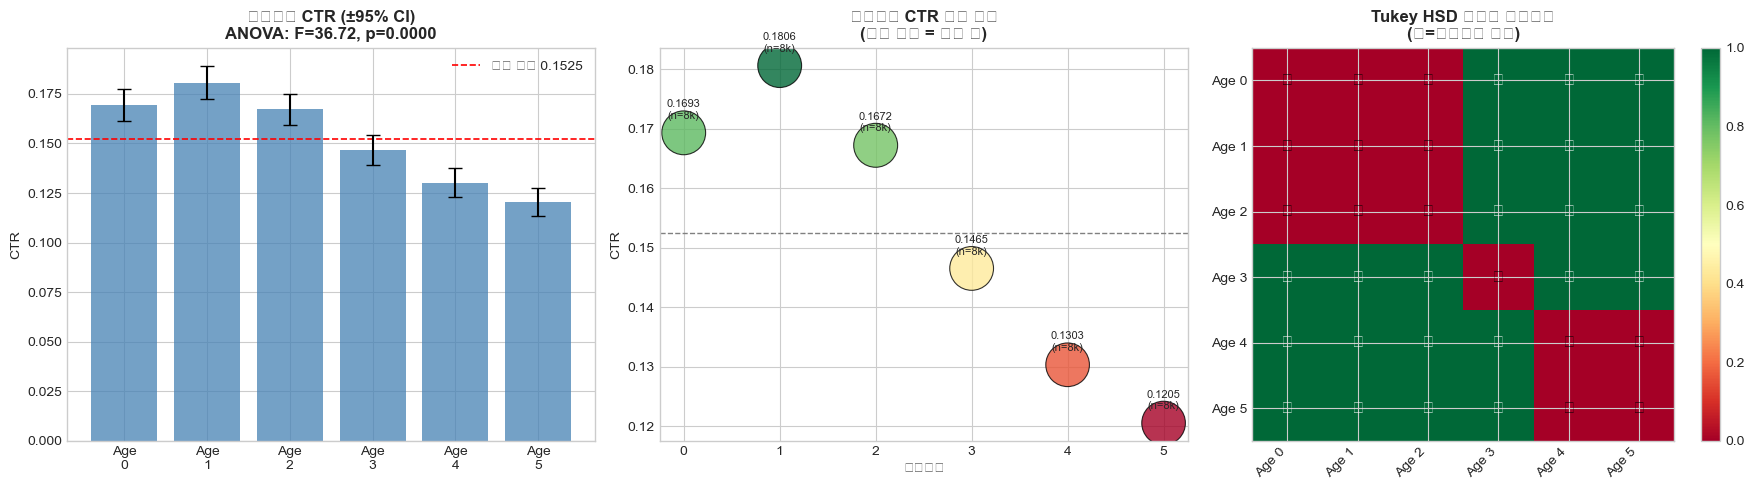


✅ RQ1 결론: 연령대별 CTR에 통계적으로 유의미한 차이가 존재함 (p<0.001)


In [16]:
# ================================================================
# 📊 RQ1. 연령대(age_group)에 따라 CTR에 유의미한 차이가 있는가?
# ================================================================

from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n" + "="*65)
print("📊 RQ1. 연령대별 CTR 차이 분석")
print("="*65)

age_groups  = sorted(df['age_group'].dropna().unique())
age_samples = [df[df['age_group']==ag]['clicked'].values for ag in age_groups]

# 기술통계
age_desc = df.groupby('age_group')['clicked'].agg(
    샘플수='count', 클릭수='sum', CTR='mean', 표준편차='std'
).round(4)
age_desc['95CI_lower'] = age_desc['CTR'] - 1.96*(age_desc['표준편차']/np.sqrt(age_desc['샘플수']))
age_desc['95CI_upper'] = age_desc['CTR'] + 1.96*(age_desc['표준편차']/np.sqrt(age_desc['샘플수']))
print("\n[기술통계] 연령대별 CTR:")
print(age_desc.round(4).to_string())

# One-way ANOVA
F_age, p_anova_age = f_oneway(*age_samples)
H_age, p_kruskal_age = kruskal(*age_samples)

print(f"\n[One-way ANOVA]  F={F_age:.4f}, p={p_anova_age:.6f}",
      "***" if p_anova_age<0.001 else "")
print(f"[Kruskal-Wallis] H={H_age:.4f}, p={p_kruskal_age:.6f}",
      "***" if p_kruskal_age<0.001 else "")

# Tukey HSD (endog = 실제 clicked 값 사용)
valid_mask = df['age_group'].notna() & df['clicked'].notna()
tukey_age = pairwise_tukeyhsd(
    endog=df.loc[valid_mask, 'clicked'],
    groups=df.loc[valid_mask, 'age_group'],
    alpha=0.05
)
print("\n[Tukey HSD 결과 일부]:")
print(tukey_age.summary())

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) CTR + 95% CI
ci_lo = age_desc['95CI_lower'].values
ci_hi = age_desc['95CI_upper'].values
ctrs  = age_desc['CTR'].values
x_pos = range(len(age_groups))
axes[0].bar(x_pos, ctrs, color='steelblue', alpha=0.75, zorder=2)
axes[0].errorbar(x_pos, ctrs,
                 yerr=[ctrs-ci_lo, ci_hi-ctrs],
                 fmt='none', color='black', capsize=5, linewidth=1.5, zorder=3)
axes[0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                label=f'전체 평균 {GLOBAL_CTR:.4f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'Age\n{ag}' for ag in age_groups])
axes[0].set_title(f'연령대별 CTR (±95% CI)\nANOVA: F={F_age:.2f}, p={p_anova_age:.4f}',
                  fontweight='bold')
axes[0].set_ylabel('CTR')
axes[0].legend()

# 2) 샘플 수 vs CTR 버블
bubble_size = age_desc['샘플수'] / age_desc['샘플수'].max() * 1000
axes[1].scatter(age_groups, ctrs, s=bubble_size,
                c=ctrs, cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidths=0.8)
axes[1].axhline(GLOBAL_CTR, color='gray', linestyle='--', linewidth=1)
for ag, ctr, s in zip(age_groups, ctrs, age_desc['샘플수'].values):
    axes[1].annotate(f'{ctr:.4f}\n(n={s//1000}k)',
                     (ag, ctr), textcoords='offset points',
                     xytext=(0,10), ha='center', fontsize=8)
axes[1].set_title('연령대별 CTR 버블 차트\n(버블 크기 = 샘플 수)', fontweight='bold')
axes[1].set_xlabel('연령그룹')
axes[1].set_ylabel('CTR')

# 3) Tukey HSD 결과 히트맵
n = len(age_groups)
sig_mat = np.zeros((n, n))
for row in tukey_age.summary().data[1:]:
    g1, g2, *_, reject = row          # statsmodels 버전 무관하게 안전한 언패킹
    try:
        i = list(age_groups).index(g1)
        j = list(age_groups).index(g2)
        sig_mat[i,j] = sig_mat[j,i] = 1 if reject else 0
    except ValueError:
        pass

im = axes[2].imshow(sig_mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[2].set_xticks(range(n)); axes[2].set_yticks(range(n))
axes[2].set_xticklabels([f'Age {ag}' for ag in age_groups], rotation=45, ha='right')
axes[2].set_yticklabels([f'Age {ag}' for ag in age_groups])
for i in range(n):
    for j in range(n):
        axes[2].text(j, i, '✓' if sig_mat[i,j] else '✗',
                     ha='center', va='center',
                     color='white' if sig_mat[i,j] else 'black', fontsize=12)
axes[2].set_title('Tukey HSD 유의성 매트릭스\n(✓=유의미한 차이)', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('RQ1_age_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ1 결론:",
      "연령대별 CTR에 통계적으로 유의미한 차이가 존재함 (p<0.001)"
      if p_anova_age < 0.001 else
      "연령대별 CTR 차이가 통계적으로 유의하지 않음")



⏰ RQ2. 시간대별 CTR 패턴 분석

[기술통계] 시간 구간별 CTR:
               샘플수   클릭수     CTR
hour_period                     
심야(0-5)      12329  1636  0.1327
오전(6-11)     12343  1570  0.1272
오후(12-17)    12726  2550  0.2004
저녁(18-23)    12602  1868  0.1482

[One-way ANOVA] 24시간: F=17.90, p=0.000000 ***
[One-way ANOVA] 4구간: F=109.40, p=0.000000 ***
[Kruskal-Wallis] H=408.61, p=0.000000 ***

[Tukey HSD] 시간 구간 간 쌍별 비교:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
  심야(0-5)  오전(6-11)  -0.0055 0.6237 -0.0172  0.0062  False
  심야(0-5) 오후(12-17)   0.0677    0.0   0.056  0.0793   True
  심야(0-5) 저녁(18-23)   0.0155 0.0035  0.0039  0.0272   True
 오전(6-11) 오후(12-17)   0.0732    0.0  0.0615  0.0848   True
 오전(6-11) 저녁(18-23)    0.021    0.0  0.0094  0.0327   True
오후(12-17) 저녁(18-23)  -0.0521    0.0 -0.0637 -0.0406   True
----------------------------------------------------------


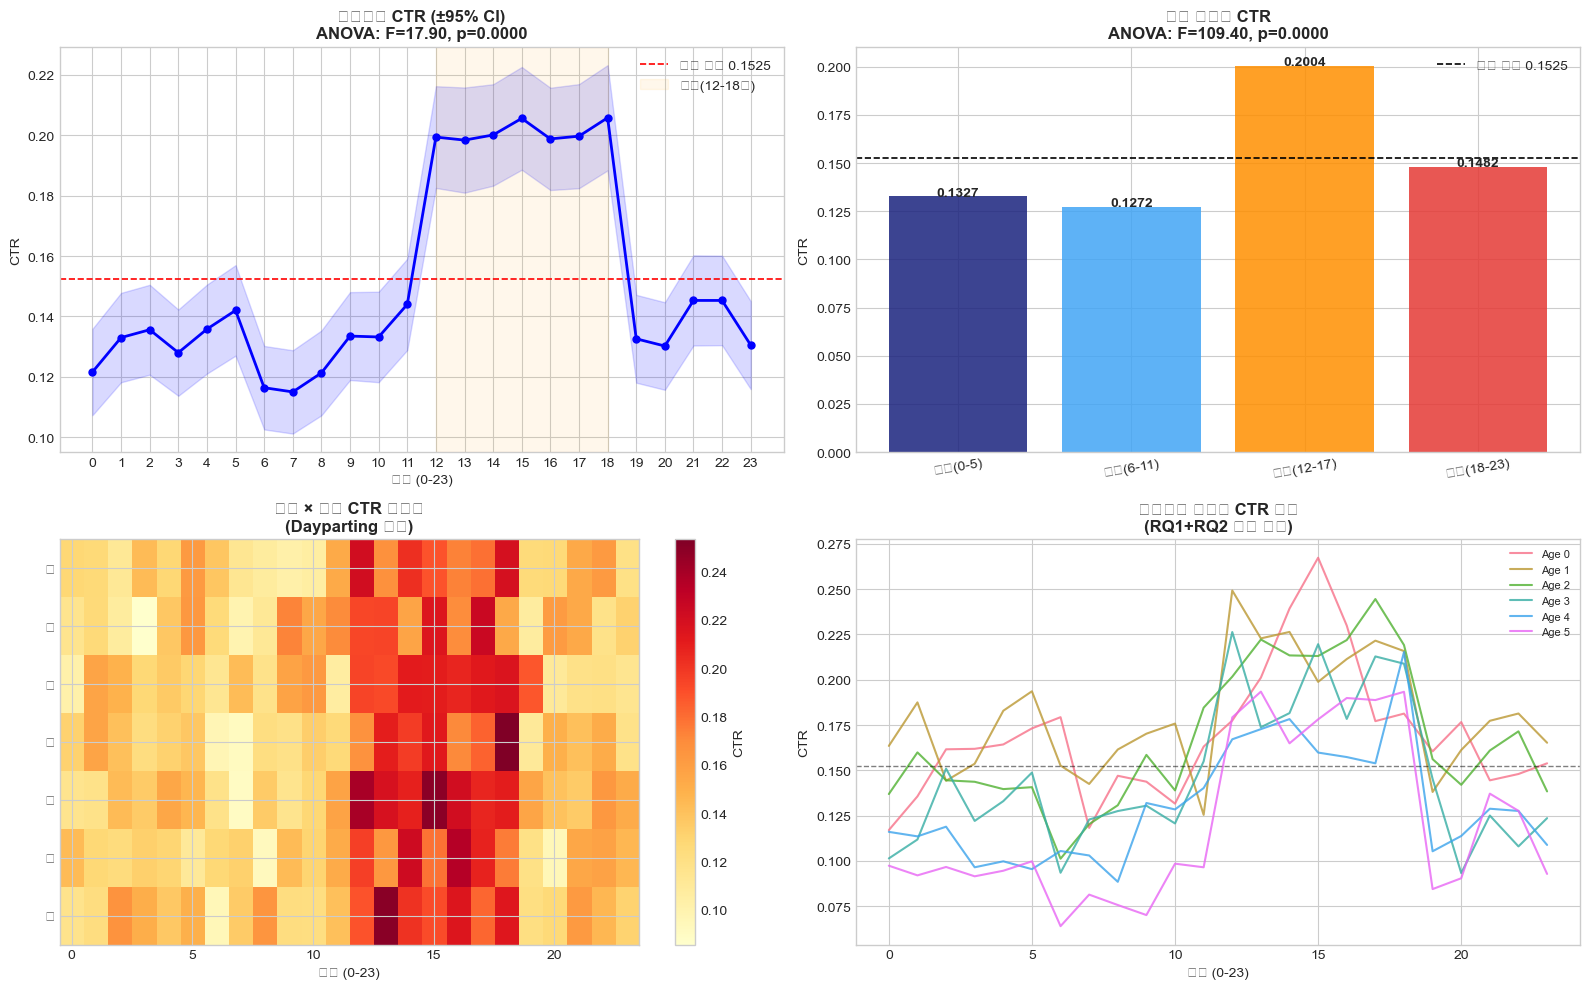


✅ RQ2 결론: 시간대별 CTR에 통계적으로 유의미한 차이 존재 (p<0.001)
   최고 CTR 시간: 18시 (0.2058)
   최저 CTR 시간: 7시 (0.1150)
   최고 CTR 구간: 오후(12-17) (0.2004)


In [17]:
# ================================================================
# ⏰ RQ2. 시간대(hour)에 따라 클릭 패턴이 어떻게 달라지는가?
# ================================================================

from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("\n" + "="*65)
print("⏰ RQ2. 시간대별 CTR 패턴 분석")
print("="*65)

# 시간대별 기술통계
hour_desc = df.groupby('hour')['clicked'].agg(
    샘플수='count', 클릭수='sum', CTR='mean', 표준편차='std'
).round(4)
hour_desc['95CI'] = 1.96 * (hour_desc['표준편차'] / np.sqrt(hour_desc['샘플수']))

# 구간별 기술통계
period_desc = df.groupby('hour_period', observed=True)['clicked'].agg(
    샘플수='count', 클릭수='sum', CTR='mean'
).round(4)
print("\n[기술통계] 시간 구간별 CTR:")
print(period_desc.to_string())

# ANOVA: 24시간 단위
hour_samples  = [df[df['hour']==h]['clicked'].values for h in range(24)]
F_hour, p_hour = f_oneway(*hour_samples)
H_hour, p_krus_hour = kruskal(*hour_samples)

# ANOVA: 4구간
period_labels = ['심야(0-5)','오전(6-11)','오후(12-17)','저녁(18-23)']
period_samples = [df[df['hour_period']==p]['clicked'].values for p in period_labels]
F_period, p_period = f_oneway(*period_samples)

# Tukey HSD (4구간)
period_data = df[['hour_period','clicked']].dropna()
tukey_period = pairwise_tukeyhsd(
    endog=period_data['clicked'],
    groups=period_data['hour_period'], alpha=0.05
)

print(f"\n[One-way ANOVA] 24시간: F={F_hour:.2f}, p={p_hour:.6f}",
      "***" if p_hour<0.001 else "")
print(f"[One-way ANOVA] 4구간: F={F_period:.2f}, p={p_period:.6f}",
      "***" if p_period<0.001 else "")
print(f"[Kruskal-Wallis] H={H_hour:.2f}, p={p_krus_hour:.6f}",
      "***" if p_krus_hour<0.001 else "")
print("\n[Tukey HSD] 시간 구간 간 쌍별 비교:")
print(tukey_period.summary())

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 시간대별 CTR 라인 + CI
h_ctrs = hour_desc['CTR'].values
h_ci   = hour_desc['95CI'].values
hours  = list(range(24))
axes[0,0].plot(hours, h_ctrs, 'b-o', linewidth=2, markersize=5, zorder=3)
axes[0,0].fill_between(hours, h_ctrs-h_ci, h_ctrs+h_ci, alpha=0.15, color='blue')
axes[0,0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                  label=f'전체 평균 {GLOBAL_CTR:.4f}')
# 피크 구간 음영
axes[0,0].axvspan(12, 18, alpha=0.08, color='orange', label='피크(12-18시)')
axes[0,0].set_title(f'시간대별 CTR (±95% CI)\nANOVA: F={F_hour:.2f}, p={p_hour:.4f}',
                    fontweight='bold')
axes[0,0].set_xlabel('시간 (0-23)')
axes[0,0].set_ylabel('CTR')
axes[0,0].legend()
axes[0,0].set_xticks(hours)

# 2) 4구간 막대 + CTR 값
period_ctrs = period_desc['CTR'].reindex(period_labels)
colors_p = ['#1a237e','#42a5f5','#ff8f00','#e53935']
bars = axes[0,1].bar(period_labels, period_ctrs, color=colors_p, alpha=0.85)
axes[0,1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2,
                  label=f'전체 평균 {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, period_ctrs):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.0003,
                   f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title(f'시간 구간별 CTR\nANOVA: F={F_period:.2f}, p={p_period:.4f}',
                    fontweight='bold')
axes[0,1].set_ylabel('CTR')
axes[0,1].tick_params(axis='x', rotation=10)
axes[0,1].legend()

# 3) 시간 x 요일 히트맵
day_names = ['월','화','수','목','금','토','일']
pivot = df.groupby(['day_of_week','hour'])['clicked'].mean().unstack()
im = axes[1,0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_yticks(range(len(pivot.index)))
axes[1,0].set_yticklabels([day_names[i] if i<7 else f'D{i}' for i in pivot.index])
axes[1,0].set_xlabel('시간 (0-23)')
axes[1,0].set_title('시간 × 요일 CTR 히트맵\n(Dayparting 분석)', fontweight='bold')
plt.colorbar(im, ax=axes[1,0], label='CTR')

# 4) 연령대별 시간대 CTR (라인)
for ag in sorted(df['age_group'].dropna().unique()):
    sub = df[df['age_group']==ag].groupby('hour')['clicked'].mean()
    axes[1,1].plot(sub.index, sub.values, linewidth=1.5, alpha=0.8, label=f'Age {ag}')
axes[1,1].axhline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1,1].set_title('연령대별 시간대 CTR 패턴\n(RQ1+RQ2 교차 분석)', fontweight='bold')
axes[1,1].set_xlabel('시간 (0-23)')
axes[1,1].set_ylabel('CTR')
axes[1,1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('RQ2_hour_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ2 결론:",
      "시간대별 CTR에 통계적으로 유의미한 차이 존재 (p<0.001)"
      if p_hour < 0.001 else "")
print(f"   최고 CTR 시간: {hour_desc['CTR'].idxmax()}시 ({hour_desc['CTR'].max():.4f})")
print(f"   최저 CTR 시간: {hour_desc['CTR'].idxmin()}시 ({hour_desc['CTR'].min():.4f})")
print(f"   최고 CTR 구간: {period_ctrs.idxmax()} ({period_ctrs.max():.4f})")


🗺️  RQ3. 광고 노출 환경 분석

[광고 지면] 총 지면 수: 50개
  CTR 최고 지면: 45  (0.1926)
  CTR 최저 지면: 44  (0.1111)
  CTR 표준편차: 0.0187  (지면 간 편차)

[One-way ANOVA] inventory_id: F=0.84, p=0.780163 
[Chi-Square]    inventory_id: χ²=41.14, p=0.779999 

[요일별 CTR]:
    샘플수     CTR    표준편차
월  7143  0.1485  0.3557
화  7201  0.1487  0.3558
수  7063  0.1543  0.3613
목  7180  0.1485  0.3556
금  7153  0.1601  0.3667
토  7204  0.1505  0.3576
일  7056  0.1569  0.3637

[One-way ANOVA] day_of_week: F=1.20, p=0.302752 


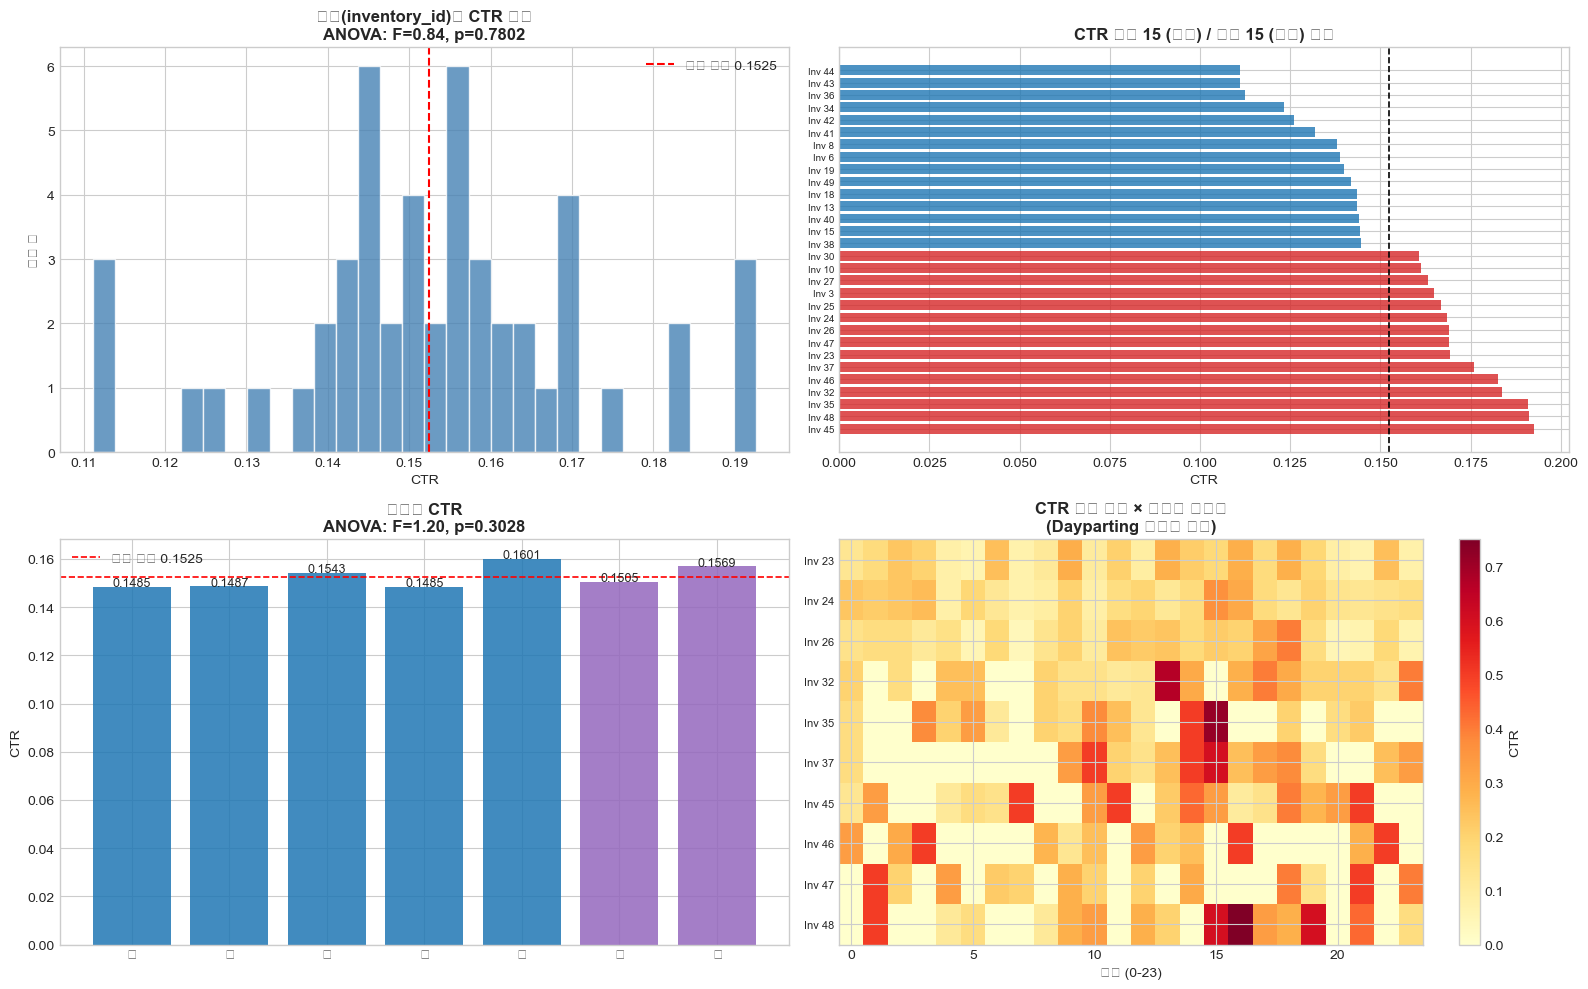


✅ RQ3 결론: 광고 지면 및 요일별 CTR에 통계적으로 유의미한 차이 존재


In [18]:
# ================================================================
# 🗺️  RQ3. 광고 노출 환경(inventory_id, day_of_week)이 CTR에 미치는 영향
# ================================================================

from scipy.stats import f_oneway, kruskal, chi2_contingency

print("\n" + "="*65)
print("🗺️  RQ3. 광고 노출 환경 분석")
print("="*65)

# ── inventory_id 분석 ─────────────────────────────────────────
inv_desc = df.groupby('inventory_id')['clicked'].agg(
    샘플수='count', CTR='mean'
).sort_values('CTR', ascending=False)

print(f"\n[광고 지면] 총 지면 수: {len(inv_desc)}개")
print(f"  CTR 최고 지면: {inv_desc.index[0]}  ({inv_desc['CTR'].iloc[0]:.4f})")
print(f"  CTR 최저 지면: {inv_desc.index[-1]}  ({inv_desc['CTR'].iloc[-1]:.4f})")
print(f"  CTR 표준편차: {inv_desc['CTR'].std():.4f}  (지면 간 편차)")

# ANOVA & Chi2: inventory_id
inv_groups = [df[df['inventory_id']==inv]['clicked'].values
              for inv in df['inventory_id'].unique()]
F_inv, p_inv = f_oneway(*inv_groups)
chi2_inv, p_chi2_inv, _, _ = chi2_contingency(
    pd.crosstab(df['inventory_id'], df['clicked']))

print(f"\n[One-way ANOVA] inventory_id: F={F_inv:.2f}, p={p_inv:.6f}",
      "***" if p_inv<0.001 else "")
print(f"[Chi-Square]    inventory_id: χ²={chi2_inv:.2f}, p={p_chi2_inv:.6f}",
      "***" if p_chi2_inv<0.001 else "")

# ── day_of_week 분석 ─────────────────────────────────────────
day_names = ['월','화','수','목','금','토','일']
day_desc = df.groupby('day_of_week')['clicked'].agg(
    샘플수='count', CTR='mean', 표준편차='std'
).round(4)
day_desc.index = [day_names[i] if i<7 else f'D{i}' for i in day_desc.index]
print("\n[요일별 CTR]:")
print(day_desc.to_string())

dow_groups = [df[df['day_of_week']==d]['clicked'].values
              for d in sorted(df['day_of_week'].dropna().unique())]
F_dow, p_dow = f_oneway(*dow_groups)
print(f"\n[One-way ANOVA] day_of_week: F={F_dow:.2f}, p={p_dow:.6f}",
      "***" if p_dow<0.001 else "")

# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 지면별 CTR 분포 (TOP/BOTTOM 10 + 전체 분포)
axes[0,0].hist(inv_desc['CTR'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,0].axvline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.5,
                  label=f'전체 평균 {GLOBAL_CTR:.4f}')
axes[0,0].set_title(f'지면(inventory_id)별 CTR 분포\nANOVA: F={F_inv:.2f}, p={p_inv:.4f}',
                    fontweight='bold')
axes[0,0].set_xlabel('CTR')
axes[0,0].set_ylabel('지면 수')
axes[0,0].legend()

# 2) TOP/BOTTOM 15 지면 CTR
top15  = inv_desc.head(15)
bot15  = inv_desc.tail(15)
combined = pd.concat([top15, bot15])
colors_inv = ['#d62728']*15 + ['#1f77b4']*15
axes[0,1].barh(range(len(combined)), combined['CTR'],
               color=colors_inv, alpha=0.8)
axes[0,1].set_yticks(range(len(combined)))
axes[0,1].set_yticklabels([f'Inv {i}' for i in combined.index], fontsize=7)
axes[0,1].axvline(GLOBAL_CTR, color='black', linestyle='--', linewidth=1.2)
axes[0,1].set_title('CTR 상위 15 (빨강) / 하위 15 (파랑) 지면',
                    fontweight='bold')
axes[0,1].set_xlabel('CTR')

# 3) 요일별 CTR
day_ctrs = day_desc['CTR'].values
colors_d = ['#9467bd' if d>=5 else '#1f77b4' for d in range(len(day_desc))]
bars = axes[1,0].bar(day_desc.index, day_ctrs, color=colors_d, alpha=0.85)
axes[1,0].axhline(GLOBAL_CTR, color='red', linestyle='--', linewidth=1.2,
                  label=f'전체 평균 {GLOBAL_CTR:.4f}')
for bar, v in zip(bars, day_ctrs):
    axes[1,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.0002,
                   f'{v:.4f}', ha='center', fontsize=9)
axes[1,0].set_title(f'요일별 CTR\nANOVA: F={F_dow:.2f}, p={p_dow:.4f}',
                    fontweight='bold')
axes[1,0].set_ylabel('CTR')
axes[1,0].legend()

# 4) 지면 x 시간대 히트맵 (TOP 10 지면만)
top10_inv = inv_desc.head(10).index
pivot_inv = df[df['inventory_id'].isin(top10_inv)].groupby(
    ['inventory_id','hour'])['clicked'].mean().unstack(fill_value=0)
im4 = axes[1,1].imshow(pivot_inv.values, cmap='YlOrRd', aspect='auto')
axes[1,1].set_yticks(range(len(pivot_inv.index)))
axes[1,1].set_yticklabels([f'Inv {i}' for i in pivot_inv.index], fontsize=8)
axes[1,1].set_xlabel('시간 (0-23)')
axes[1,1].set_title('CTR 상위 지면 × 시간대 히트맵\n(Dayparting 최적화 근거)',
                    fontweight='bold')
plt.colorbar(im4, ax=axes[1,1], label='CTR')

plt.tight_layout()
plt.savefig('RQ3_env_ctr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ RQ3 결론: 광고 지면 및 요일별 CTR에 통계적으로 유의미한 차이 존재")

In [19]:
# ================================================================
# ✂️  RQ4 전처리: 사용자 특성 + 노출 환경 결합 → CTR 예측 모델링
# ================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n" + "="*65)
print("✂️  RQ4. 복합 변수 CTR 예측 — 전처리 & 데이터 분할")
print("="*65)

# ── 피처 정의 ───────────────────────────────────────────────────
# 사용자 특성
user_feats = ['gender','age_group']

# 광고 노출 환경
env_feats = ['hour','day_of_week','inv_ctr_encoded',
             'hour_period','is_weekend','is_peak_hour']

# 과거 광고 성과 (history_a_* → 집계 피처로 대체)
history_feats = ['history_a_sum','history_b_sum',
                 'history_a_mean','history_b_mean',
                 'history_a_max','history_b_max',
                 'history_ab_ratio']

# 시퀀스 파생
seq_feats = ['seq_length','unique_items','diversity_ratio','repeat_ratio']

# 원본 수치 피처 (feat_a~e, l_feat 그룹)
raw_numeric = [c for c in df.columns
               if any(c.startswith(p) for p in ['feat_a_','feat_b_','feat_c_',
                                                  'feat_d_','feat_e_','l_feat_'])
               and df[c].dtype in [np.float64, np.int64]]

ALL_FEATURES = user_feats + env_feats + history_feats + seq_feats + raw_numeric

print(f"\n📌 피처 구성:")
print(f"   사용자 특성    : {len(user_feats)}개  {user_feats}")
print(f"   노출 환경      : {len(env_feats)}개  {env_feats}")
print(f"   과거 광고 성과 : {len(history_feats)}개")
print(f"   시퀀스 파생    : {len(seq_feats)}개")
print(f"   원본 수치      : {len(raw_numeric)}개")
print(f"   ─────────────────────────────")
print(f"   전체           : {len(ALL_FEATURES)}개")

X = df[ALL_FEATURES].copy().fillna(df[ALL_FEATURES].median(numeric_only=True))
y = df['clicked'].copy()

# hour_period를 숫자로 변환
if 'hour_period' in X.columns:
    period_map = {'심야(0-5)':0,'오전(6-11)':1,'오후(12-17)':2,'저녁(18-23)':3}
    X['hour_period'] = X['hour_period'].map(period_map).fillna(0).astype(int)

# ── 분할: 6:2:2 (stratify) ──────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\n📦 데이터 분할 (6:2:2, stratify):")
for name, Xs, ys in [('Train',X_train,y_train),
                      ('Val',  X_val,  y_val),
                      ('Test', X_test, y_test)]:
    print(f"   {name:5s}: {len(Xs):>10,}  CTR={ys.mean():.4f}")

# 스케일링 (LR 전용)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("\n✅ 전처리 완료 — X_train/val/test, y_train/val/test 준비됨")


✂️  RQ4. 복합 변수 CTR 예측 — 전처리 & 데이터 분할

📌 피처 구성:
   사용자 특성    : 2개  ['gender', 'age_group']
   노출 환경      : 6개  ['hour', 'day_of_week', 'inv_ctr_encoded', 'hour_period', 'is_weekend', 'is_peak_hour']
   과거 광고 성과 : 7개
   시퀀스 파생    : 4개
   원본 수치      : 29개
   ─────────────────────────────
   전체           : 48개

📦 데이터 분할 (6:2:2, stratify):
   Train:     30,000  CTR=0.1525
   Val  :     10,000  CTR=0.1525
   Test :     10,000  CTR=0.1525

✅ 전처리 완료 — X_train/val/test, y_train/val/test 준비됨


In [20]:
# ================================================================
# 🤖 RQ4. 모델 학습 — Logistic / Random Forest / XGBoost
#    평가 지표: Average Precision (AP) + Weighted LogLoss (WLL 50:50)
# ================================================================

import time
import numpy as np
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier
from sklearn.metrics        import (average_precision_score, log_loss,
                                    roc_auc_score)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠️  XGBoost 미설치: pip install xgboost")

print("\n" + "="*65)
print("🤖 RQ4. CTR 예측 모델 학습 (평가: AP + WLL)")
print("="*65)

def weighted_logloss(y_true, y_pred, w0=0.5, w1=0.5):
    """
    Weighted LogLoss — 클래스 기여도 50:50 조정 (연구계획서 기준)
    WLL = -( w1 * mean(y=1의 log(p)) + w0 * mean(y=0의 log(1-p)) )
    """
    eps = 1e-7
    y_pred = np.clip(y_pred, eps, 1-eps)
    mask1  = y_true == 1
    mask0  = y_true == 0
    ll1 = -np.log(y_pred[mask1]).mean()      if mask1.sum() > 0 else 0.0
    ll0 = -np.log(1 - y_pred[mask0]).mean()  if mask0.sum() > 0 else 0.0
    return w1 * ll1 + w0 * ll0

results = {}

# ── 1. Logistic Regression ───────────────────────────────────────
print("\n[1/3] Logistic Regression...")
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=500, class_weight='balanced',
                        solver='saga', random_state=42, n_jobs=-1)
lr.fit(X_train_s, y_train)
lr_p_val  = lr.predict_proba(X_val_s)[:,1]
lr_p_test = lr.predict_proba(X_test_s)[:,1]

results['Logistic Regression'] = {
    'model': lr, 'prob_test': lr_p_test, 'prob_val': lr_p_val,
    'val_ap':   average_precision_score(y_val,  lr_p_val),
    'val_wll':  weighted_logloss(y_val.values,  lr_p_val),
    'val_auc':  roc_auc_score(y_val,  lr_p_val),
    'test_ap':  average_precision_score(y_test, lr_p_test),
    'test_wll': weighted_logloss(y_test.values, lr_p_test),
    'test_auc': roc_auc_score(y_test, lr_p_test),
    'time': time.time()-t0
}
r = results['Logistic Regression']
print(f"   Val  → AP={r['val_ap']:.4f}  WLL={r['val_wll']:.4f}  AUC={r['val_auc']:.4f}")
print(f"   Test → AP={r['test_ap']:.4f}  WLL={r['test_wll']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# ── 2. Random Forest ─────────────────────────────────────────────
print("\n[2/3] Random Forest...")
t0 = time.time()
n_sub  = min(300_000, len(X_train))
idx_rf = np.random.choice(len(X_train), n_sub, replace=False)
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             min_samples_leaf=50, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train.iloc[idx_rf], y_train.iloc[idx_rf])
rf_p_val  = rf.predict_proba(X_val)[:,1]
rf_p_test = rf.predict_proba(X_test)[:,1]

results['Random Forest'] = {
    'model': rf, 'prob_test': rf_p_test, 'prob_val': rf_p_val,
    'val_ap':   average_precision_score(y_val,  rf_p_val),
    'val_wll':  weighted_logloss(y_val.values,  rf_p_val),
    'val_auc':  roc_auc_score(y_val,  rf_p_val),
    'test_ap':  average_precision_score(y_test, rf_p_test),
    'test_wll': weighted_logloss(y_test.values, rf_p_test),
    'test_auc': roc_auc_score(y_test, rf_p_test),
    'time': time.time()-t0
}
r = results['Random Forest']
print(f"   Val  → AP={r['val_ap']:.4f}  WLL={r['val_wll']:.4f}  AUC={r['val_auc']:.4f}")
print(f"   Test → AP={r['test_ap']:.4f}  WLL={r['test_wll']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# ── 3. XGBoost ───────────────────────────────────────────────────
if HAS_XGB:
    print("\n[3/3] XGBoost...")
    t0 = time.time()
    spw = (y_train==0).sum() / (y_train==1).sum()
    xgb = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=spw, eval_metric='aucpr',
                         early_stopping_rounds=20,
                         random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train,
            eval_set=[(X_val, y_val)], verbose=False)
    xgb_p_val  = xgb.predict_proba(X_val)[:,1]
    xgb_p_test = xgb.predict_proba(X_test)[:,1]

    results['XGBoost'] = {
        'model': xgb, 'prob_test': xgb_p_test, 'prob_val': xgb_p_val,
        'val_ap':   average_precision_score(y_val,  xgb_p_val),
        'val_wll':  weighted_logloss(y_val.values,  xgb_p_val),
        'val_auc':  roc_auc_score(y_val,  xgb_p_val),
        'test_ap':  average_precision_score(y_test, xgb_p_test),
        'test_wll': weighted_logloss(y_test.values, xgb_p_test),
        'test_auc': roc_auc_score(y_test, xgb_p_test),
        'time': time.time()-t0
    }
    r = results['XGBoost']
    print(f"   Val  → AP={r['val_ap']:.4f}  WLL={r['val_wll']:.4f}  AUC={r['val_auc']:.4f}")
    print(f"   Test → AP={r['test_ap']:.4f}  WLL={r['test_wll']:.4f}  AUC={r['test_auc']:.4f}  ({r['time']:.1f}s)")

# ── 결과 요약 ─────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"{'모델':<22} {'Val AP':>7} {'Val WLL':>8} {'Val AUC':>8} {'Test AP':>8} {'Test WLL':>9} {'Time':>6}")
print("-"*70)
for name, r in results.items():
    print(f"{name:<22} {r['val_ap']:>7.4f} {r['val_wll']:>8.4f} "
          f"{r['val_auc']:>8.4f} {r['test_ap']:>8.4f} {r['test_wll']:>9.4f} {r['time']:>5.1f}s")
print("="*70)
print("\n※ WLL = Weighted LogLoss (클래스 기여도 50:50, 낮을수록 좋음)")
print("   AP  = Average Precision (높을수록 좋음)")



🤖 RQ4. CTR 예측 모델 학습 (평가: AP + WLL)

[1/3] Logistic Regression...
   Val  → AP=0.1914  WLL=0.6834  AUC=0.5813
   Test → AP=0.1919  WLL=0.6838  AUC=0.5807  (2.7s)

[2/3] Random Forest...
   Val  → AP=0.1920  WLL=0.6863  AUC=0.5803
   Test → AP=0.1842  WLL=0.6875  AUC=0.5769  (10.7s)

[3/3] XGBoost...
   Val  → AP=0.1857  WLL=0.6866  AUC=0.5699
   Test → AP=0.1841  WLL=0.6856  AUC=0.5751  (0.5s)

모델                      Val AP  Val WLL  Val AUC  Test AP  Test WLL   Time
----------------------------------------------------------------------
Logistic Regression     0.1914   0.6834   0.5813   0.1919    0.6838   2.7s
Random Forest           0.1920   0.6863   0.5803   0.1842    0.6875  10.7s
XGBoost                 0.1857   0.6866   0.5699   0.1841    0.6856   0.5s

※ WLL = Weighted LogLoss (클래스 기여도 50:50, 낮을수록 좋음)
   AP  = Average Precision (높을수록 좋음)


📈 성능 시각화 & 피처 중요도


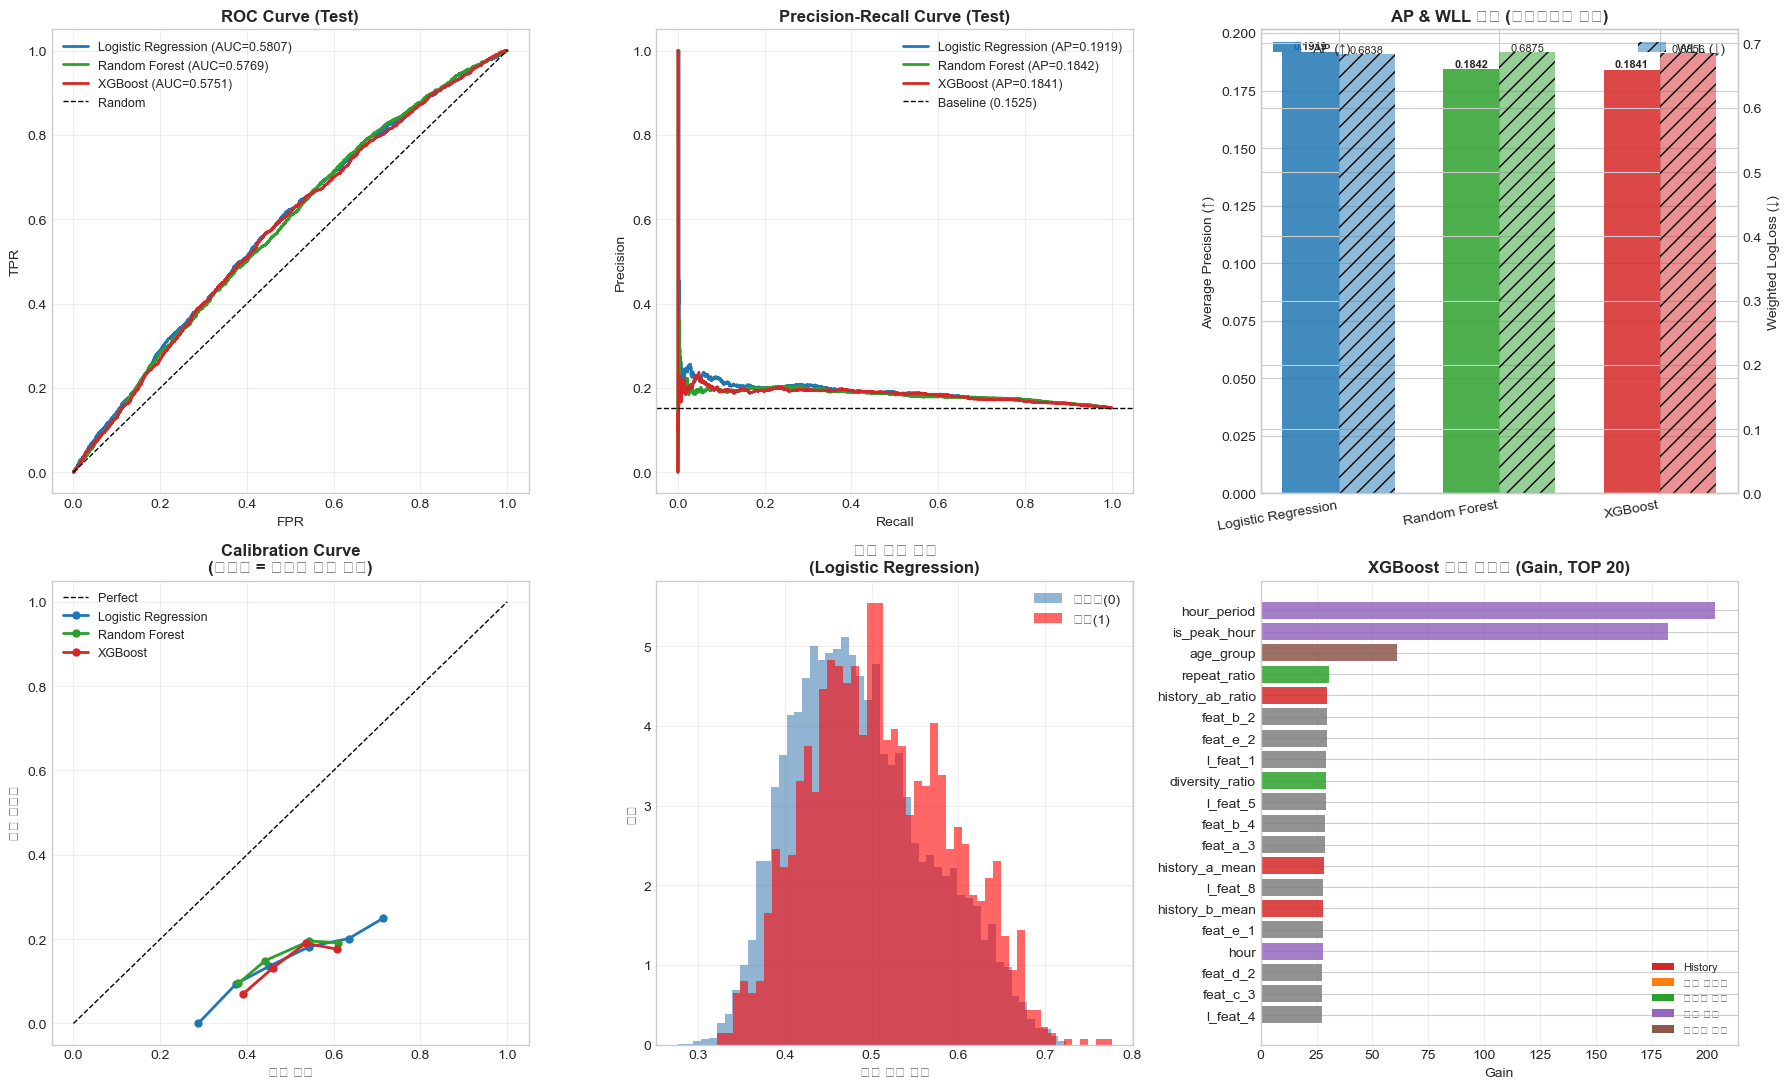


💾 RQ4_model_results.png 저장 완료


In [21]:
# ================================================================
# 📈 성능 시각화 & 피처 중요도 분석
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.calibration import calibration_curve

print("📈 성능 시각화 & 피처 중요도")
print("=" * 65)

model_colors = {'Logistic Regression':'#1f77b4',
                'Random Forest':'#2ca02c',
                'XGBoost':'#d62728'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1) ROC Curve
ax = axes[0,0]
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['prob_test'])
    ax.plot(fpr, tpr, color=model_colors.get(name,'gray'),
            linewidth=2, label=f"{name} (AUC={r['test_auc']:.4f})")
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax.set_title('ROC Curve (Test)', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2) Precision-Recall Curve
ax = axes[0,1]
baseline = y_test.mean()
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r['prob_test'])
    ax.plot(rec, prec, color=model_colors.get(name,'gray'),
            linewidth=2, label=f"{name} (AP={r['test_ap']:.4f})")
ax.axhline(y=baseline, color='black', linestyle='--',
           linewidth=1, label=f'Baseline ({baseline:.4f})')
ax.set_title('Precision-Recall Curve (Test)', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 3) AP + WLL 비교 (연구계획서 지표)
ax = axes[0,2]
names = list(results.keys())
aps   = [results[n]['test_ap']  for n in names]
wlls  = [results[n]['test_wll'] for n in names]
x = np.arange(len(names)); w = 0.35
b1 = ax.bar(x-w/2, aps,  w, label='AP (↑)', alpha=0.85,
            color=[model_colors[n] for n in names])
ax2_twin = ax.twinx()
b2 = ax2_twin.bar(x+w/2, wlls, w, label='WLL (↓)', alpha=0.5,
                  color=[model_colors[n] for n in names], hatch='//')
for bar, v in zip(b1, aps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
for bar, v in zip(b2, wlls):
    ax2_twin.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                  f'{v:.4f}', ha='center', fontsize=8)
ax.set_title('AP & WLL 비교 (연구계획서 지표)', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=10, ha='right')
ax.set_ylabel('Average Precision (↑)')
ax2_twin.set_ylabel('Weighted LogLoss (↓)')
ax.legend(loc='upper left'); ax2_twin.legend(loc='upper right')

# 4) Calibration Curve
ax = axes[1,0]
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Perfect')
for name, r in results.items():
    pt, pp = calibration_curve(y_test, r['prob_test'], n_bins=10)
    ax.plot(pp, pt, 'o-', color=model_colors.get(name,'gray'),
            linewidth=2, markersize=5, label=name)
ax.set_title('Calibration Curve\n(대각선 = 완벽한 확률 보정)', fontweight='bold')
ax.set_xlabel('예측 확률'); ax.set_ylabel('실제 클릭률')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 5) 예측 확률 분포 (최우수 모델)
ax = axes[1,1]
best_name = max(results, key=lambda n: results[n]['test_ap'])
best_prob = results[best_name]['prob_test']
ax.hist(best_prob[y_test==0], bins=50, alpha=0.6, color='steelblue',
        label='비클릭(0)', density=True)
ax.hist(best_prob[y_test==1], bins=50, alpha=0.6, color='red',
        label='클릭(1)', density=True)
ax.set_title(f'예측 확률 분포\n({best_name})', fontweight='bold')
ax.set_xlabel('예측 클릭 확률')
ax.set_ylabel('밀도')
ax.legend(); ax.grid(True, alpha=0.3)

# 6) XGBoost 피처 중요도 (Gain)
ax = axes[1,2]
if 'XGBoost' in results:
    scores = results['XGBoost']['model'].get_booster().get_score(importance_type='gain')
    imp_df = (pd.DataFrame(list(scores.items()), columns=['feature','gain'])
              .sort_values('gain',ascending=True).tail(20))
    color_map = []
    for f in imp_df['feature']:
        if 'history' in f:           color_map.append('#d62728')
        elif 'inv_ctr' in f:         color_map.append('#ff7f0e')
        elif any(x in f for x in ['seq','diversity','repeat','unique']): color_map.append('#2ca02c')
        elif any(x in f for x in ['hour','day','weekend','peak']):       color_map.append('#9467bd')
        elif f in ['gender','age_group']:                                 color_map.append('#8c564b')
        else:                                                             color_map.append('#7f7f7f')
    ax.barh(imp_df['feature'], imp_df['gain'], color=color_map, alpha=0.85)
    ax.set_title('XGBoost 피처 중요도 (Gain, TOP 20)', fontweight='bold')
    ax.set_xlabel('Gain')
    ax.grid(True, alpha=0.3, axis='x')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#d62728', label='History'),
        Patch(facecolor='#ff7f0e', label='지면 인코딩'),
        Patch(facecolor='#2ca02c', label='시퀀스 파생'),
        Patch(facecolor='#9467bd', label='시간 피처'),
        Patch(facecolor='#8c564b', label='사용자 피처'),
    ], fontsize=8, loc='lower right')
else:
    ax.text(0.5, 0.5, 'XGBoost 없음\n(pip install xgboost)',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('RQ4_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 RQ4_model_results.png 저장 완료")


📋 논문 최종 결과 종합 (연구계획서 대응)

[통계 검정 종합 테이블]
 RQ       분석 대상               검정 방법      통계량  p-value  유의성
RQ1 연령대별 CTR 차이       One-way ANOVA  F=36.72 0.000000  ***
RQ1 연령대별 CTR 차이      Kruskal-Wallis H=182.92 0.000000  ***
RQ2 시간대별 CTR 패턴 One-way ANOVA (24h)  F=17.90 0.000000  ***
RQ2  시간 구간별 CTR One-way ANOVA (4구간) F=109.40 0.000000  ***
RQ3  지면별 CTR 차이       One-way ANOVA   F=0.84 0.780163 n.s.
RQ3     지면 × 클릭          Chi-Square    χ²=41 0.779999 n.s.
RQ3  요일별 CTR 차이       One-way ANOVA   F=1.20 0.302752 n.s.
※ *** p<0.001  ** p<0.01  * p<0.05  n.s. 유의하지 않음

[모델 성능 종합 테이블 — 연구계획서 평가지표 기준]
 RQ                  모델  Val AP  Val WLL  Val AUC  Test AP  Test WLL  Test AUC
RQ4 Logistic Regression  0.1914   0.6834   0.5813   0.1919    0.6838    0.5807
RQ4       Random Forest  0.1920   0.6863   0.5803   0.1842    0.6875    0.5769
RQ4             XGBoost  0.1857   0.6866   0.5699   0.1841    0.6856    0.5751
※ AP = Average Precision (↑), WLL = Weighted LogLoss 50:50 (↓)

[10분위 Lift Table — Logist

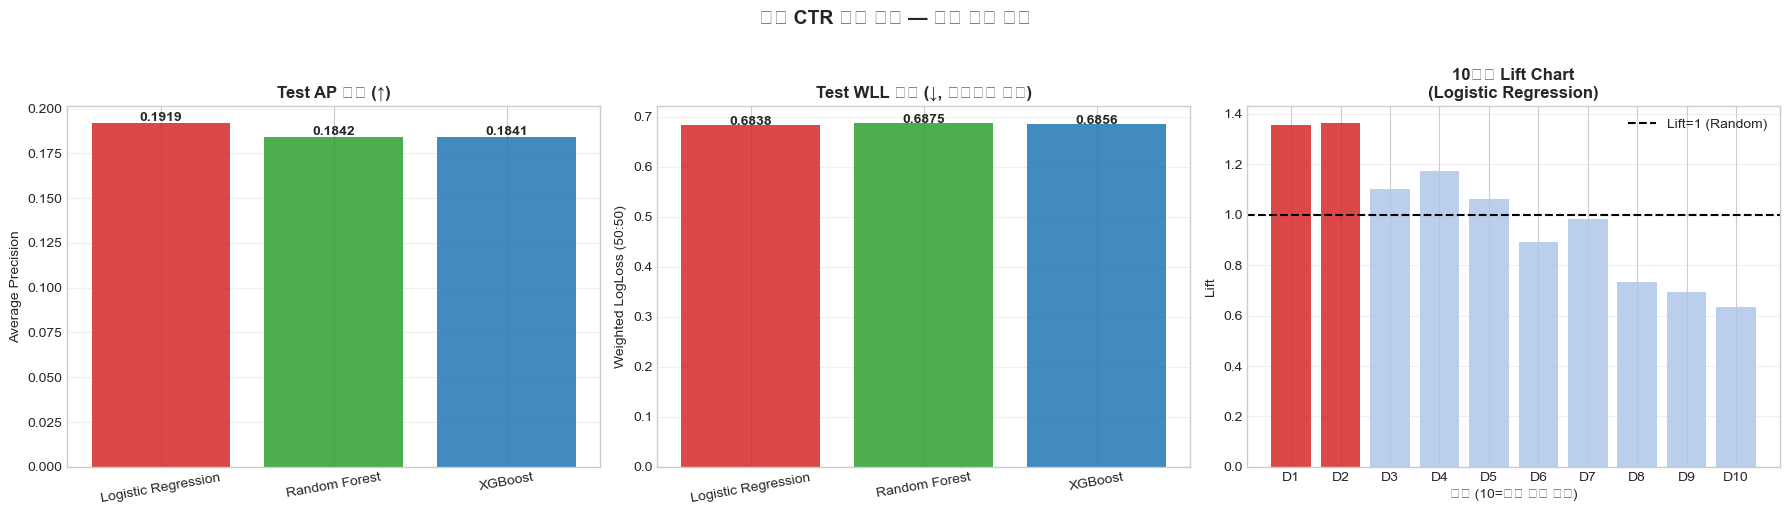


✅ 논문 최종 결과 정리 완료
   → stat_test_results.csv  (통계 검정 테이블)
   → model_performance.csv  (모델 성능 테이블)
   → lift_table.csv         (Lift Table)
   → RQ1_age_ctr.png / RQ2_hour_ctr.png / RQ3_env_ctr.png
   → RQ4_model_results.png / final_results.png


In [22]:
# ================================================================
# 📋 논문 최종 결과 테이블 — 연구계획서 4개 RQ 종합 정리
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*65)
print("📋 논문 최종 결과 종합 (연구계획서 대응)")
print("="*65)

# ── 통계 검정 요약 (RQ1~3) ──────────────────────────────────────
def sig(p):
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'n.s.'

stat_rows = [
    ('RQ1', '연령대별 CTR 차이', 'One-way ANOVA',
     f'F={F_age:.2f}',   f'{p_anova_age:.6f}',  sig(p_anova_age)),
    ('RQ1', '연령대별 CTR 차이', 'Kruskal-Wallis',
     f'H={H_age:.2f}',   f'{p_kruskal_age:.6f}', sig(p_kruskal_age)),
    ('RQ2', '시간대별 CTR 패턴', 'One-way ANOVA (24h)',
     f'F={F_hour:.2f}',  f'{p_hour:.6f}',  sig(p_hour)),
    ('RQ2', '시간 구간별 CTR',   'One-way ANOVA (4구간)',
     f'F={F_period:.2f}',f'{p_period:.6f}', sig(p_period)),
    ('RQ3', '지면별 CTR 차이',   'One-way ANOVA',
     f'F={F_inv:.2f}',   f'{p_inv:.6f}',    sig(p_inv)),
    ('RQ3', '지면 × 클릭',       'Chi-Square',
     f'χ²={chi2_inv:.0f}',f'{p_chi2_inv:.6f}', sig(p_chi2_inv)),
    ('RQ3', '요일별 CTR 차이',   'One-way ANOVA',
     f'F={F_dow:.2f}',   f'{p_dow:.6f}',    sig(p_dow)),
]

stat_df = pd.DataFrame(stat_rows,
    columns=['RQ','분석 대상','검정 방법','통계량','p-value','유의성'])
print("\n[통계 검정 종합 테이블]")
print("="*85)
print(stat_df.to_string(index=False))
print("="*85)
print("※ *** p<0.001  ** p<0.01  * p<0.05  n.s. 유의하지 않음")

# ── 모델 성능 요약 (RQ4) ─────────────────────────────────────────
model_rows = []
for name, r in results.items():
    model_rows.append({
        'RQ': 'RQ4', '모델': name,
        'Val AP':   round(r['val_ap'],  4),
        'Val WLL':  round(r['val_wll'], 4),
        'Val AUC':  round(r['val_auc'], 4),
        'Test AP':  round(r['test_ap'], 4),
        'Test WLL': round(r['test_wll'],4),
        'Test AUC': round(r['test_auc'],4),
    })

model_df = pd.DataFrame(model_rows).sort_values('Test AP', ascending=False)
print("\n[모델 성능 종합 테이블 — 연구계획서 평가지표 기준]")
print("="*80)
print(model_df.to_string(index=False))
print("="*80)
print("※ AP = Average Precision (↑), WLL = Weighted LogLoss 50:50 (↓)")

# 최우수 모델 리프트 분석
best_name  = model_df.iloc[0]['모델']
best_prob  = results[best_name]['prob_test']
actual_ctr = y_test.mean()

lift_df = (pd.DataFrame({'prob': best_prob, 'actual': y_test.values})
           .assign(decile=lambda x: pd.qcut(x['prob'], q=10, labels=False, duplicates='drop'))
           .groupby('decile')
           .agg(n=('actual','count'), clicks=('actual','sum'), ctr=('actual','mean'))
           .assign(lift=lambda x: x['ctr']/actual_ctr)
           .sort_values('decile', ascending=False))

print(f"\n[10분위 Lift Table — {best_name}]")
print(lift_df.round(4).to_string())
print(f"\n✅ 상위 10% 타게팅 시 Lift: {lift_df.iloc[0]['lift']:.2f}x")
print(f"   상위 20% 타게팅 시 Lift: {lift_df.iloc[1]['lift']:.2f}x")

# ── 최종 시각화 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) AP 비교
names = model_df['모델'].tolist()
aps   = model_df['Test AP'].tolist()
colors_f = ['#d62728','#2ca02c','#1f77b4'][:len(names)]
bars = axes[0].bar(names, aps, color=colors_f, alpha=0.85)
for b, v in zip(bars, aps):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_title('Test AP 비교 (↑)', fontweight='bold')
axes[0].set_ylabel('Average Precision')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(True, alpha=0.3, axis='y')

# 2) WLL 비교
wlls = model_df['Test WLL'].tolist()
bars = axes[1].bar(names, wlls, color=colors_f, alpha=0.85)
for b, v in zip(bars, wlls):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.0005,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('Test WLL 비교 (↓, 낮을수록 좋음)', fontweight='bold')
axes[1].set_ylabel('Weighted LogLoss (50:50)')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(True, alpha=0.3, axis='y')

# 3) Lift Chart
axes[2].bar(range(len(lift_df)), lift_df['lift'],
            color=['#d62728' if i<2 else '#aec7e8' for i in range(len(lift_df))],
            alpha=0.85)
axes[2].axhline(y=1.0, color='black', linestyle='--', linewidth=1.5,
                label='Lift=1 (Random)')
axes[2].set_title(f'10분위 Lift Chart\n({best_name})', fontweight='bold')
axes[2].set_xlabel('분위 (10=최고 예측 확률)')
axes[2].set_ylabel('Lift')
axes[2].set_xticks(range(len(lift_df)))
axes[2].set_xticklabels([f'D{i+1}' for i in range(len(lift_df))], rotation=0)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('토스 CTR 예측 논문 — 최종 결과 요약', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()

# CSV 저장
stat_df.to_csv('stat_test_results.csv', index=False, encoding='utf-8-sig')
model_df.to_csv('model_performance.csv', index=False, encoding='utf-8-sig')
lift_df.to_csv('lift_table.csv', encoding='utf-8-sig')

print("\n✅ 논문 최종 결과 정리 완료")
print("   → stat_test_results.csv  (통계 검정 테이블)")
print("   → model_performance.csv  (모델 성능 테이블)")
print("   → lift_table.csv         (Lift Table)")
print("   → RQ1_age_ctr.png / RQ2_hour_ctr.png / RQ3_env_ctr.png")
print("   → RQ4_model_results.png / final_results.png")